# Topic Modeling dengan LDA (Latent Dirichlet Allocation)

Notebook ini membangun model **LDA (Latent Dirichlet Allocation)** untuk topic modeling pada abstrak artikel ilmiah hasil scraping DOAJ, menggunakan representasi **Bag-of-Words (BoW)**.

**Alur kerja notebook:**
1. Import library & load data
2. Tuning parameter dictionary (`no_below`, `no_above`) dan `passes`
3. Pembuatan dictionary & corpus untuk 2 skenario preprocessing: **Non-Lematisasi** dan **Lematisasi**
4. Topic modeling LDA + pencarian jumlah topik (k) optimal berdasarkan Coherence Score
5. Visualisasi topik dengan pyLDAvis
6. Analisis hasil, perbandingan skenario, dan penentuan model final
7. Interpretasi & pelabelan topik pada model final


## 1. Import Library

Seluruh dependency yang dibutuhkan notebook ini diinstal dan diimpor di satu tempat supaya mudah ditelusuri dan dijalankan ulang.

**Kebutuhan:**
- `pandas`, `numpy`: manipulasi data
- `gensim`: pembuatan dictionary/corpus BoW dan pemodelan LDA
- `matplotlib`, `seaborn`: visualisasi
- `pyLDAvis`: visualisasi interaktif topik LDA
- `openpyxl`: membaca/menulis file Excel


In [2]:
!pip install gensim pyLDAvis openpyxl -q

In [3]:
import os
import ast
import warnings

# Data wrangling & visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from IPython.display import display, HTML

# Gensim (Dictionary, Corpus, LDA, Coherence)
from gensim import corpora, models
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

warnings.filterwarnings("ignore")
pyLDAvis.enable_notebook()

## 2. Load Data

Memuat dataset hasil preprocessing (`data_clean_doaj.xlsx`) yang sudah memiliki kolom teks dalam dua versi:
- `stopword_removed` — teks tanpa lemmatization (skenario **Non-Lematisasi**)
- `lemmatization` — teks dengan lemmatization (skenario **Lematisasi**)

Kedua kolom ini disimpan dalam format string representasi list (misal `"['kata1', 'kata2']"`), sehingga perlu dikonversi kembali menjadi list Python sebelum diproses Gensim.


In [4]:
df_lda = pd.read_excel('/content/data_clean_doaj (1).xlsx')

print("Ukuran data :", df_lda.shape)
print("Kolom       :", list(df_lda.columns))
df_lda.head()

Ukuran data : (3326, 8)
Kolom       : ['Main_Keyword', 'Year', 'Title', 'Journal', 'clean_text', 'tokenizing', 'stopword_removed', 'lemmatization']


,Main_Keyword,Year,Title,Journal,clean_text,tokenizing,stopword_removed,lemmatization
0,sentiment analysis,2020,Automatic Visual Sentiment Analysis with Convo...,International Journal of Industrial Engineerin...,today digital world demands about automated se...,"['today', 'digital', 'world', 'demands', 'abou...","['demands', 'automated', 'sentiment_analysis',...","['demand', 'automated', 'sentiment_analysis', ..."
1,sentiment analysis,2020,Predicting Supervise Machine Learning Performa...,IEEE Access,sentiment_analysis is focused on mining opinio...,"['sentiment_analysis', 'is', 'focused', 'on', ...","['sentiment_analysis', 'mining', 'opinion', 'c...","['sentiment_analysis', 'mining', 'opinion', 'c..."
2,sentiment analysis,2020,Unsupervised Semantic Approach of Aspect-Based...,IEEE Access,aspect_based_sentiment_analysis has recently a...,"['aspect_based_sentiment_analysis', 'has', 're...","['aspect_based_sentiment_analysis', 'attracted...","['aspect_based_sentiment_analysis', 'attracted..."
3,sentiment analysis,2020,Exploring Diverse Features for Sentiment Quant...,IEEE Access,in the era of web online forums blogs and twit...,"['in', 'the', 'era', 'of', 'web', 'online', 'f...","['twitter', 'primary', 'sources', 'views', 'op...","['twitter', 'primary', 'source', 'view', 'opin..."
4,sentiment analysis,2020,Evaluation of Sentiment Analysis in Finance: F...,IEEE Access,financial and economic news is continuously mo...,"['financial', 'and', 'economic', 'news', 'is',...","['financial', 'economic', 'news', 'continuousl...","['financial', 'economic', 'news', 'continuousl..."


In [24]:
def fix_format(text):
    """Mengubah string representasi list (misal "['kata1','kata2']") menjadi list Python asli."""
    if isinstance(text, list):
        return text
    if isinstance(text, str) and text.strip().startswith('['):
        try:
            return ast.literal_eval(text)
        except Exception:
            return []
    return []


# Kolom teks yang digunakan: non-lematisasi & lematisasi
COLS_USED = ["stopword_removed", "lemmatization"]

for col in COLS_USED:
    if col in df_lda.columns:
        df_lda[col] = df_lda[col].apply(fix_format)
    else:
        print(f"[WARNING] Kolom '{col}' tidak ditemukan di dataframe.")

print("Kolom yang digunakan:", COLS_USED)
print("\nContoh stopword_removed :", df_lda['stopword_removed'].iloc[0][:5])
print("Contoh lemmatization    :", df_lda['lemmatization'].iloc[0][:5])

Kolom yang digunakan: ['stopword_removed', 'lemmatization']

Contoh stopword_removed : ['demands', 'automated', 'sentiment_analysis', 'visual', 'content']
Contoh lemmatization    : ['demand', 'automated', 'sentiment_analysis', 'visual', 'content']


## 3. Tuning Parameter Dictionary (`no_below` & `no_above`)

Sebelum membangun model LDA, ukuran vocabulary perlu disaring menggunakan parameter Gensim `filter_extremes`:
- **`no_below`** — kata dibuang jika muncul di kurang dari N dokumen (membuang kata yang terlalu jarang/tidak representatif)
- **`no_above`** — kata dibuang jika muncul di lebih dari N% dokumen (membuang kata yang terlalu umum/tidak diskriminatif)

Tahap ini mencoba berbagai kombinasi `no_below` dan `no_above` untuk melihat pengaruhnya terhadap ukuran vocabulary, pada dua skenario teks: **Non-Lematisasi** dan **Lematisasi**.


In [6]:
no_below_list = [2, 3, 5, 6, 7, 9, 10]
no_above_list = [0.01, 0.02, 0.05, 0.3, 0.6, 1.0]

### 3.1 Non-Lematisasi

In [25]:
texts_nonlemma = df_lda['stopword_removed'].tolist()

dictionary_asli_nonlemma = corpora.Dictionary(texts_nonlemma)
vocab_asli_nonlemma = len(dictionary_asli_nonlemma)

print("=" * 50)
print("NON-LEMATISASI")
print("=" * 50)
print(f"Vocabulary asli (tanpa filter): {vocab_asli_nonlemma}")

results_nonlemma = []
for no_below in no_below_list:
    for no_above in no_above_list:
        dictionary = corpora.Dictionary(texts_nonlemma)
        dictionary.filter_extremes(no_below=no_below, no_above=no_above)

        results_nonlemma.append({
            'no_below': no_below,
            'no_above': no_above,
            'vocab_size': len(dictionary)
        })

df_tuning_nonlemma = pd.DataFrame(results_nonlemma)
print("\nJumlah kata per kombinasi (Non-Lematisasi):")
print(df_tuning_nonlemma)

NON-LEMATISASI
Vocabulary asli (tanpa filter): 20597

Jumlah kata per kombinasi (Non-Lematisasi):
    no_below  no_above  vocab_size
0          2      0.01        8957
1          2      0.02        9746
2          2      0.05       10435
3          2      0.30       10794
4          2      0.60       10797
5          2      1.00       10797
6          3      0.01        6410
7          3      0.02        7199
8          3      0.05        7888
9          3      0.30        8247
10         3      0.60        8250
11         3      1.00        8250
12         5      0.01        4236
13         5      0.02        5025
14         5      0.05        5714
15         5      0.30        6073
16         5      0.60        6076
17         5      1.00        6076
18         6      0.01        3626
19         6      0.02        4415
20         6      0.05        5104
21         6      0.30        5463
22         6      0.60        5466
23         6      1.00        5466
24         7      0.01     

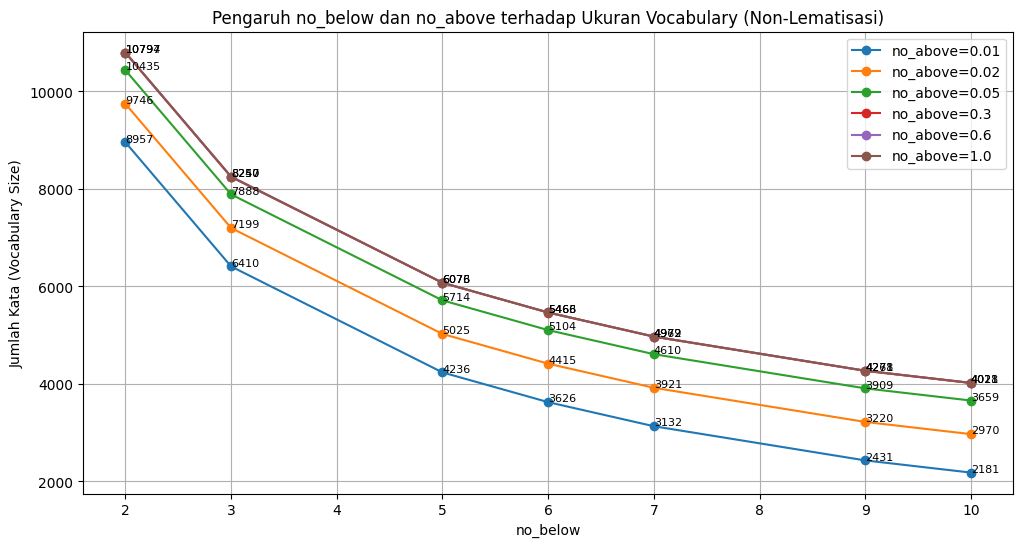

In [26]:
plt.figure(figsize=(12, 6))

for no_above in no_above_list:
    subset = df_tuning_nonlemma[df_tuning_nonlemma['no_above'] == no_above]
    plt.plot(subset['no_below'], subset['vocab_size'], marker='o', label=f'no_above={no_above}')

    for x, y in zip(subset['no_below'], subset['vocab_size']):
        plt.text(x, y + 10, str(y), fontsize=8)

plt.title('Pengaruh no_below dan no_above terhadap Ukuran Vocabulary (Non-Lematisasi)')
plt.xlabel('no_below')
plt.ylabel('Jumlah Kata (Vocabulary Size)')
plt.legend()
plt.grid(True)
plt.show()

### 3.2 Lematisasi

In [27]:
texts_lemma = df_lda['lemmatization'].tolist()

dictionary_asli_lemma = corpora.Dictionary(texts_lemma)
vocab_asli_lemma = len(dictionary_asli_lemma)

print("=" * 50)
print("LEMATISASI")
print("=" * 50)
print(f"Vocabulary asli (tanpa filter): {vocab_asli_lemma}")

results_lemma = []
for no_below in no_below_list:
    for no_above in no_above_list:
        dictionary = corpora.Dictionary(texts_lemma)
        dictionary.filter_extremes(no_below=no_below, no_above=no_above)

        results_lemma.append({
            'no_below': no_below,
            'no_above': no_above,
            'vocab_size': len(dictionary)
        })

df_tuning_lemma = pd.DataFrame(results_lemma)
print("\nJumlah kata per kombinasi (Lematisasi):")
print(df_tuning_lemma)

LEMATISASI
Vocabulary asli (tanpa filter): 18483

Jumlah kata per kombinasi (Lematisasi):
    no_below  no_above  vocab_size
0          2      0.01        7863
1          2      0.02        8563
2          2      0.05        9187
3          2      0.30        9562
4          2      0.60        9567
5          2      1.00        9567
6          3      0.01        5610
7          3      0.02        6310
8          3      0.05        6934
9          3      0.30        7309
10         3      0.60        7314
11         3      1.00        7314
12         5      0.01        3679
13         5      0.02        4379
14         5      0.05        5003
15         5      0.30        5378
16         5      0.60        5383
17         5      1.00        5383
18         6      0.01        3164
19         6      0.02        3864
20         6      0.05        4488
21         6      0.30        4863
22         6      0.60        4868
23         6      1.00        4868
24         7      0.01        2739


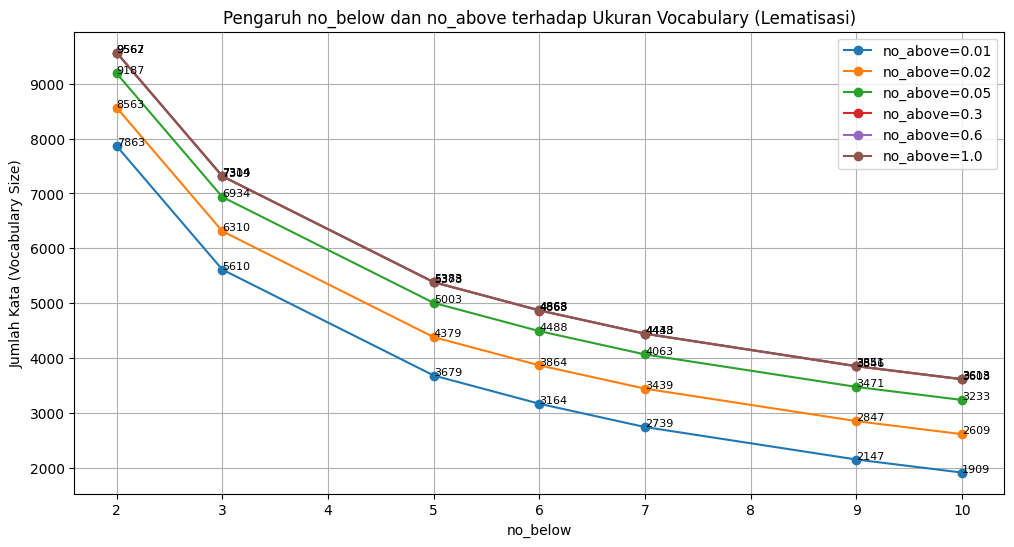

In [28]:
plt.figure(figsize=(12, 6))

for no_above in no_above_list:
    subset = df_tuning_lemma[df_tuning_lemma['no_above'] == no_above]
    plt.plot(subset['no_below'], subset['vocab_size'], marker='o', label=f'no_above={no_above}')

    for x, y in zip(subset['no_below'], subset['vocab_size']):
        plt.text(x, y + 10, str(y), fontsize=8)

plt.title('Pengaruh no_below dan no_above terhadap Ukuran Vocabulary (Lematisasi)')
plt.xlabel('no_below')
plt.ylabel('Jumlah Kata (Vocabulary Size)')
plt.legend()
plt.grid(True)
plt.show()

### 3.3 Penetapan Parameter Dictionary Terpilih

`no_below=5` dipilih karena kata yang muncul di hanya 1–2 artikel dari seluruh corpus DOAJ hampir pasti tidak akan membentuk topik yang bermakna, sementara kata yang sudah muncul di 5 dokumen berbeda mulai menunjukkan pola yang lebih stabil.

Untuk `no_above`, dua nilai dipertahankan sebagai pembanding pada tahap selanjutnya:
- **`no_above=0.05`** — filter ketat, membuang kata yang muncul di lebih dari 5% dokumen
- **`no_above=0.6`** — filter longgar, membuang kata yang muncul di lebih dari 60% dokumen

Kombinasi ini dipakai untuk membandingkan dampak tingkat filtering kata umum terhadap kualitas topik (Coherence Score) pada tahap pemodelan LDA berikutnya.


In [29]:
NO_BELOW_NONLEMMA = 5
NO_ABOVE_NONLEMMA = 0.05   # akan dibandingkan juga dengan 0.6 pada tahap pemodelan

NO_BELOW_LEMMA    = 5
NO_ABOVE_LEMMA    = 0.05   # akan dibandingkan juga dengan 0.6 pada tahap pemodelan

print("Parameter dasar yang digunakan:")
print(f"  Non-Lematisasi -> no_below={NO_BELOW_NONLEMMA}, no_above={NO_ABOVE_NONLEMMA}")
print(f"  Lematisasi     -> no_below={NO_BELOW_LEMMA}, no_above={NO_ABOVE_LEMMA}")

Parameter dasar yang digunakan:
  Non-Lematisasi -> no_below=5, no_above=0.05
  Lematisasi     -> no_below=5, no_above=0.05


## 4. Tuning Parameter `passes`

Parameter `passes` menentukan berapa kali model LDA "membaca ulang" seluruh corpus selama training. Semakin besar `passes`, model punya kesempatan lebih banyak untuk konvergen, tapi waktu komputasi juga makin lama.

Tahap ini mencoba beberapa nilai `passes` pada jumlah topik tetap (`NUM_TOPICS_TEMP`) untuk melihat titik di mana Coherence Score mulai stabil, sebelum nilai `passes` ini dipakai pada seluruh eksperimen pencarian k optimal.


In [30]:
NUM_TOPICS_TEMP = 10        # jumlah topik sementara, hanya untuk tuning passes
passes_list_tuning = [10, 15, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

# Dictionary & corpus awal (memakai no_above=0.05) untuk keperluan tuning passes
dict_nonlemma_tn = corpora.Dictionary(texts_nonlemma)
dict_nonlemma_tn.filter_extremes(no_below=NO_BELOW_NONLEMMA, no_above=NO_ABOVE_NONLEMMA)
corpus_nonlemma_tn = [dict_nonlemma_tn.doc2bow(t) for t in texts_nonlemma]

dict_lemma_tn = corpora.Dictionary(texts_lemma)
dict_lemma_tn.filter_extremes(no_below=NO_BELOW_LEMMA, no_above=NO_ABOVE_LEMMA)
corpus_lemma_tn = [dict_lemma_tn.doc2bow(t) for t in texts_lemma]

print("=== Corpus untuk tuning passes siap ===")
print(f"  Non-Lematisasi -> vocab: {len(dict_nonlemma_tn)}, docs: {len(corpus_nonlemma_tn)}")
print(f"  Lematisasi     -> vocab: {len(dict_lemma_tn)}, docs: {len(corpus_lemma_tn)}")

=== Corpus untuk tuning passes siap ===
  Non-Lematisasi -> vocab: 5714, docs: 3326
  Lematisasi     -> vocab: 5003, docs: 3326


In [31]:
def tune_passes(corpus, dictionary, texts, passes_list, label):
    """Melatih LDA pada beberapa nilai `passes` dan mengevaluasi coherence & perplexity-nya."""
    print("=" * 55)
    print(f"  TUNING PASSES -- {label}")
    print("=" * 55)

    results = []
    for p in passes_list:
        lda = models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=NUM_TOPICS_TEMP,
            passes=p,
            random_state=42,
            alpha="auto",
            eta="auto"
        )
        coherence = CoherenceModel(
            model=lda, texts=texts, dictionary=dictionary, coherence="c_v"
        ).get_coherence()
        perplexity = lda.log_perplexity(corpus)

        results.append({"passes": p, "coherence": coherence, "perplexity": perplexity})
        print(f"  passes={p:2d}  |  coherence={coherence:.4f}  |  log-perplexity={perplexity:.4f}")

    return pd.DataFrame(results)


df_passes_nonlemma = tune_passes(corpus_nonlemma_tn, dict_nonlemma_tn, texts_nonlemma,
                                  passes_list_tuning, "NON-LEMATISASI")
df_passes_lemma = tune_passes(corpus_lemma_tn, dict_lemma_tn, texts_lemma,
                               passes_list_tuning, "LEMATISASI")

  TUNING PASSES -- NON-LEMATISASI
  passes=10  |  coherence=0.4257  |  log-perplexity=-8.1029
  passes=15  |  coherence=0.4352  |  log-perplexity=-8.0859
  passes=20  |  coherence=0.4569  |  log-perplexity=-8.0765
  passes=21  |  coherence=0.4603  |  log-perplexity=-8.0752
  passes=22  |  coherence=0.4614  |  log-perplexity=-8.0740
  passes=23  |  coherence=0.4617  |  log-perplexity=-8.0731
  passes=24  |  coherence=0.4575  |  log-perplexity=-8.0722
  passes=25  |  coherence=0.4577  |  log-perplexity=-8.0713
  passes=26  |  coherence=0.4618  |  log-perplexity=-8.0706
  passes=27  |  coherence=0.4618  |  log-perplexity=-8.0698
  passes=28  |  coherence=0.4618  |  log-perplexity=-8.0691
  passes=29  |  coherence=0.4619  |  log-perplexity=-8.0685
  passes=30  |  coherence=0.4619  |  log-perplexity=-8.0678
  TUNING PASSES -- LEMATISASI
  passes=10  |  coherence=0.3854  |  log-perplexity=-7.9471
  passes=15  |  coherence=0.3993  |  log-perplexity=-7.9326
  passes=20  |  coherence=0.4089  | 

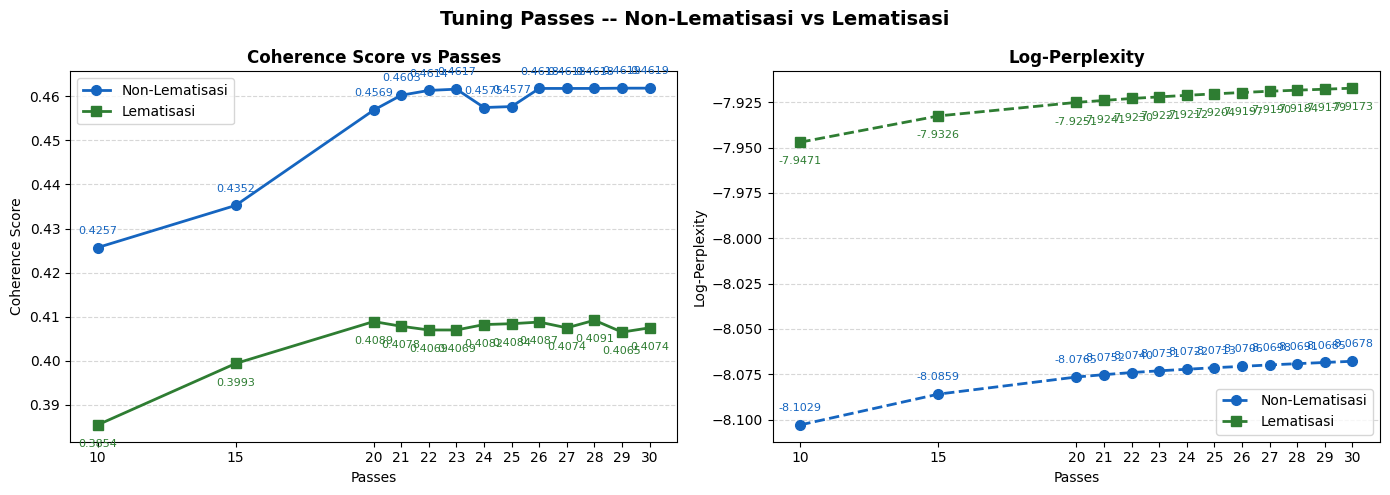

Passes terbaik (Non-Lematisasi): 29
Passes terbaik (Lematisasi)    : 28


In [32]:
def annotate_line(ax, x_vals, y_vals, color, offset_y=10):
    for x, y in zip(x_vals, y_vals):
        ax.annotate(f"{y:.4f}", (x, y), textcoords="offset points",
                    xytext=(0, offset_y), ha="center", fontsize=8, color=color)


COLOR_NL = "#1565C0"   # biru  - non-lematisasi
COLOR_L  = "#2E7D32"   # hijau - lematisasi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Tuning Passes -- Non-Lematisasi vs Lematisasi", fontsize=14, fontweight="bold")

# Grafik Coherence
ax = axes[0]
ax.plot(df_passes_nonlemma["passes"], df_passes_nonlemma["coherence"],
        "o-", color=COLOR_NL, linewidth=2, markersize=7, label="Non-Lematisasi")
ax.plot(df_passes_lemma["passes"], df_passes_lemma["coherence"],
        "s-", color=COLOR_L, linewidth=2, markersize=7, label="Lematisasi")
annotate_line(ax, df_passes_nonlemma["passes"], df_passes_nonlemma["coherence"], COLOR_NL, 10)
annotate_line(ax, df_passes_lemma["passes"], df_passes_lemma["coherence"], COLOR_L, -16)
ax.set_title("Coherence Score vs Passes", fontsize=12, fontweight="bold")
ax.set_xlabel("Passes"); ax.set_ylabel("Coherence Score")
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(ticker.FixedLocator(passes_list_tuning))
ax.yaxis.grid(True, linestyle="--", alpha=0.5)

# Grafik Perplexity
ax = axes[1]
ax.plot(df_passes_nonlemma["passes"], df_passes_nonlemma["perplexity"],
        "o--", color=COLOR_NL, linewidth=2, markersize=7, label="Non-Lematisasi")
ax.plot(df_passes_lemma["passes"], df_passes_lemma["perplexity"],
        "s--", color=COLOR_L, linewidth=2, markersize=7, label="Lematisasi")
annotate_line(ax, df_passes_nonlemma["passes"], df_passes_nonlemma["perplexity"], COLOR_NL, 10)
annotate_line(ax, df_passes_lemma["passes"], df_passes_lemma["perplexity"], COLOR_L, -16)
ax.set_title("Log-Perplexity", fontsize=12, fontweight="bold")
ax.set_xlabel("Passes"); ax.set_ylabel("Log-Perplexity")
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(ticker.FixedLocator(passes_list_tuning))
ax.yaxis.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("tuning_passes_bow.png", dpi=150, bbox_inches="tight")
plt.show()

best_p_nonlemma = df_passes_nonlemma.loc[df_passes_nonlemma["coherence"].idxmax(), "passes"]
best_p_lemma = df_passes_lemma.loc[df_passes_lemma["coherence"].idxmax(), "passes"]
print(f"Passes terbaik (Non-Lematisasi): {best_p_nonlemma}")
print(f"Passes terbaik (Lematisasi)    : {best_p_lemma}")

# Berdasarkan tuning di atas, passes=25 dipilih sebagai nilai final untuk seluruh eksperimen selanjutnya
PASSES_FINAL = 25

## 5. Pembuatan Dictionary & Corpus per Skenario

Pada tahap ini, dictionary dan corpus BoW dibangun untuk dua skenario preprocessing (**Non-Lematisasi** dan **Lematisasi**), masing-masing dengan dua varian filter `no_above` (**0.05** dan **0.6**), menggunakan `no_below=5` yang sudah ditetapkan sebelumnya.

Total terbentuk **4 kombinasi dictionary/corpus** yang akan dijadikan dasar pencarian jumlah topik (k) optimal pada tahap selanjutnya.


In [37]:
def prepare_gensim(text_list, no_below=None, no_above=None):
    """Membangun dictionary Gensim dan corpus BoW dari list teks, dengan filter opsional.

    Selain dictionary & corpus (SAMA seperti sebelumnya, tidak berubah), fungsi ini
    juga mengembalikan `removed_info`: daftar kata yang terhapus oleh masing-masing
    kriteria filter, supaya bisa ditelusuri kata apa saja yang hilang dan kenapa.
      - removed_by_no_below : kata yang muncul di TERLALU SEDIKIT dokumen (df < no_below)
      - removed_by_no_above : kata yang muncul di TERLALU BANYAK dokumen (df > no_above * jumlah_dokumen)
    """
    dictionary = corpora.Dictionary(text_list)

    removed_below = pd.DataFrame(columns=["kata", "jumlah_dokumen"])
    removed_above = pd.DataFrame(columns=["kata", "jumlah_dokumen", "persentase_dokumen"])

    if no_below is not None and no_above is not None:
        num_docs = dictionary.num_docs
        dfs_before = dictionary.dfs.copy()                      # document frequency SEBELUM difilter
        id2token_before = {v: k for k, v in dictionary.token2id.items()}
        threshold_above = no_above * num_docs

        below_rows, above_rows = [], []
        for token_id, df in dfs_before.items():
            word = id2token_before[token_id]
            if df < no_below:
                below_rows.append({"kata": word, "jumlah_dokumen": df})
            elif df > threshold_above:
                above_rows.append({
                    "kata": word,
                    "jumlah_dokumen": df,
                    "persentase_dokumen": round(df / num_docs * 100, 2)
                })

        # Kolom di-set eksplisit supaya DataFrame tetap punya struktur yang benar
        # walaupun below_rows/above_rows kosong (0 kata terhapus) -- pd.DataFrame([])
        # tanpa argumen columns akan menghasilkan DataFrame TANPA kolom sama sekali,
        # yang bikin sort_values("jumlah_dokumen") error dengan KeyError.
        removed_below = (pd.DataFrame(below_rows, columns=["kata", "jumlah_dokumen"])
                          .sort_values("jumlah_dokumen", ascending=True)
                          .reset_index(drop=True))
        removed_above = (pd.DataFrame(above_rows, columns=["kata", "jumlah_dokumen", "persentase_dokumen"])
                          .sort_values("jumlah_dokumen", ascending=False)
                          .reset_index(drop=True))

        # Filter dictionary yang SESUNGGUHNYA dipakai untuk training -- persis seperti sebelumnya
        dictionary.filter_extremes(no_below=no_below, no_above=no_above)

    corpus = [dictionary.doc2bow(text) for text in text_list]

    removed_info = {
        "no_below": no_below,
        "no_above": no_above,
        "jumlah_kata_terhapus_no_below": len(removed_below),
        "jumlah_kata_terhapus_no_above": len(removed_above),
        "removed_by_no_below": removed_below,
        "removed_by_no_above": removed_above,
    }
    return dictionary, corpus, removed_info


no_below_values = [5]
no_above_values = [0.05, 0.6]

### 5.1 Skenario Non-Lematisasi

In [38]:
gensim_nonlemma = {}

for nb in no_below_values:
    for na in no_above_values:
        label = f"non_lemma_nb{nb}_na{na}"

        dictionary, corpus, removed_info = prepare_gensim(df_lda['stopword_removed'].tolist(), nb, na)

        gensim_nonlemma[label] = {
            "dict": dictionary,
            "corpus": corpus,
            "no_below": nb,
            "no_above": na,
            "removed_info": removed_info
        }

print("Skenario Non-Lematisasi terbentuk:", list(gensim_nonlemma.keys()))

Skenario Non-Lematisasi terbentuk: ['non_lemma_nb5_na0.05', 'non_lemma_nb5_na0.6']


### 5.2 Skenario Lematisasi

In [39]:
gensim_lemma = {}

for nb in no_below_values:
    for na in no_above_values:
        label = f"lemma_nb{nb}_na{na}"

        dictionary, corpus, removed_info = prepare_gensim(df_lda['lemmatization'].tolist(), nb, na)

        gensim_lemma[label] = {
            "dict": dictionary,
            "corpus": corpus,
            "no_below": nb,
            "no_above": na,
            "removed_info": removed_info
        }

print("Skenario Lematisasi terbentuk:", list(gensim_lemma.keys()))

Skenario Lematisasi terbentuk: ['lemma_nb5_na0.05', 'lemma_nb5_na0.6']


### 5.3 Ringkasan Ukuran Vocabulary & Dokumen per Skenario

In [40]:
def summarize(data, nama, summary_list):
    for label, val in data.items():
        summary_list.append({
            "skenario": nama,
            "eksperimen": label,
            "no_below": val["no_below"],
            "no_above": val["no_above"],
            "jumlah_vocab": len(val["dict"]),
            "jumlah_dokumen": len(val["corpus"])
        })


summary = []
summarize(gensim_nonlemma, "non_lematisasi", summary)
summarize(gensim_lemma, "lematisasi", summary)

df_vocab_summary = pd.DataFrame(summary).sort_values(by="jumlah_vocab", ascending=False).reset_index(drop=True)

print(f"Total kombinasi dictionary/corpus yang terbentuk: {len(df_vocab_summary)}")
display(df_vocab_summary)

Total kombinasi dictionary/corpus yang terbentuk: 4


,skenario,eksperimen,no_below,no_above,jumlah_vocab,jumlah_dokumen
0,non_lematisasi,non_lemma_nb5_na0.6,5,0.60,6076,3326
1,non_lematisasi,non_lemma_nb5_na0.05,5,0.05,5714,3326
2,lematisasi,lemma_nb5_na0.6,5,0.60,5383,3326
3,lematisasi,lemma_nb5_na0.05,5,0.05,5003,3326


In [41]:
def print_removed_summary(label, removed_info, preview_n=15):
    """Cetak ringkasan singkat + preview kata yang terhapus untuk satu skenario."""
    n_below = removed_info["jumlah_kata_terhapus_no_below"]
    n_above = removed_info["jumlah_kata_terhapus_no_above"]
    nb_val = removed_info["no_below"]
    na_val = removed_info["no_above"]

    print(f"\n{'=' * 65}")
    print(f"{label}  (no_below={nb_val}, no_above={na_val})")
    print(f"{'=' * 65}")
    print(f"Kata terhapus karena no_below (jarang muncul) : {n_below} kata")
    print(f"Kata terhapus karena no_above (terlalu sering) : {n_above} kata")

    print(f"\n-- Contoh {min(preview_n, n_below)} kata terhapus (no_below), paling jarang muncul --")
    display(removed_info["removed_by_no_below"].head(preview_n))

    print(f"\n-- Contoh {min(preview_n, n_above)} kata terhapus (no_above), paling sering muncul --")
    display(removed_info["removed_by_no_above"].head(preview_n))


# Kumpulkan removed_info dari seluruh skenario (non-lematisasi & lematisasi)
all_removed_info = {}
for label, data in gensim_nonlemma.items():
    all_removed_info[label] = data["removed_info"]
for label, data in gensim_lemma.items():
    all_removed_info[label] = data["removed_info"]

for label, removed_info in all_removed_info.items():
    print_removed_summary(label, removed_info)



non_lemma_nb5_na0.05  (no_below=5, no_above=0.05)
Kata terhapus karena no_below (jarang muncul) : 14521 kata
Kata terhapus karena no_above (terlalu sering) : 362 kata

-- Contoh 15 kata terhapus (no_below), paling jarang muncul --


,kata,jumlah_dokumen
0,hris,1
1,motivational,1
2,researchgate,1
3,neurotechnology,1
4,intradialytic,1
5,hypotension,1
6,cramps,1
7,dhr,1
8,brazilians,1
9,consistence,1



-- Contoh 15 kata terhapus (no_above), paling sering muncul --


,kata,jumlah_dokumen,persentase_dokumen
0,accuracy,1452,43.66
1,models,1381,41.52
2,features,999,30.04
3,machine_learning,964,28.98
4,selection,891,26.79
5,classification,881,26.49
6,high,879,26.43
7,however,878,26.40
8,techniques,871,26.19
9,reduction,814,24.47



non_lemma_nb5_na0.6  (no_below=5, no_above=0.6)
Kata terhapus karena no_below (jarang muncul) : 14521 kata
Kata terhapus karena no_above (terlalu sering) : 0 kata

-- Contoh 15 kata terhapus (no_below), paling jarang muncul --


...

,kata,jumlah_dokumen,persentase_dokumen
0,accuracy,1480,44.50
1,model,1381,41.52
2,algorithm,1149,34.55
3,technique,1089,32.74
4,feature,999,30.04
5,machine_learning,964,28.98
6,selection,895,26.91
7,classification,890,26.76
8,high,879,26.43
9,however,878,26.40



lemma_nb5_na0.6  (no_below=5, no_above=0.6)
Kata terhapus karena no_below (jarang muncul) : 13100 kata
Kata terhapus karena no_above (terlalu sering) : 0 kata

-- Contoh 15 kata terhapus (no_below), paling jarang muncul --


,kata,jumlah_dokumen
0,dynamodb,1
1,hmi,1
2,calorie,1
3,mycotoxin,1
4,microbe,1
5,diluting,1
6,micronutrient,1
7,staple,1
8,compulsory,1
9,chose,1



-- Contoh 0 kata terhapus (no_above), paling sering muncul --


,kata,jumlah_dokumen,persentase_dokumen


In [46]:
def save_removed_words_excel(all_removed_info, output_path="lda_results/removed_words_no_below_no_above.xlsx"):
    """Menyimpan seluruh daftar kata terhapus (per skenario) ke satu file Excel,
    dengan 2 sheet per skenario: '<skenario>_no_below' dan '<skenario>_no_above'.
    Juga menambahkan 1 sheet ringkasan jumlah kata terhapus per skenario.
    """
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    ringkasan_rows = []
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        for label, removed_info in all_removed_info.items():
            ringkasan_rows.append({
                "skenario": label,
                "no_below": removed_info["no_below"],
                "no_above": removed_info["no_above"],
                "jumlah_kata_terhapus_no_below": removed_info["jumlah_kata_terhapus_no_below"],
                "jumlah_kata_terhapus_no_above": removed_info["jumlah_kata_terhapus_no_above"],
            })

            base_name = label[:24]

            sheet_below = f"{base_name}_below"[:31]
            removed_info["removed_by_no_below"].to_excel(writer, sheet_name=sheet_below, index=False)

            sheet_above = f"{base_name}_above"[:31]
            removed_info["removed_by_no_above"].to_excel(writer, sheet_name=sheet_above, index=False)

        df_ringkasan = pd.DataFrame(ringkasan_rows)
        df_ringkasan.to_excel(writer, sheet_name="ringkasan", index=False)

        for sheet_name in writer.sheets:
            ws = writer.sheets[sheet_name]
            for col in ws.columns:
                max_len = max(len(str(cell.value)) if cell.value else 0 for cell in col)
                ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 60)

    print(f"\u2714 Daftar kata terhapus (no_below & no_above) tersimpan di:\n{output_path}")
    return output_path


removed_words_excel_path = save_removed_words_excel(all_removed_info)

✔ Daftar kata terhapus (no_below & no_above) tersimpan di:
lda_results/removed_words_no_below_no_above.xlsx


## 6. Topic Modeling dengan LDA

### 6.1 Fungsi Evaluasi: Mencari k (Jumlah Topik) Optimal

Fungsi `evaluate_lda_multi_passes` melatih model LDA untuk rentang jumlah topik (`k`) tertentu, lalu menghitung **Coherence Score** dan **Perplexity** pada tiap k — ini dasar untuk menentukan jumlah topik optimal pada tahap selanjutnya.


In [ ]:
def evaluate_lda_multi_passes(corpus, dictionary, texts, passes_list, start=2, limit=16, step=1):
    """Melatih LDA untuk rentang k=[start, limit) dan mengevaluasi coherence + perplexity tiap k."""
    results = []
    topic_range = list(range(start, limit, step))

    for p in passes_list:
        print(f"\n🔁 Evaluasi passes = {p}")

        for k in topic_range:
            model = LdaModel(
                corpus=corpus,
                id2word=dictionary,
                num_topics=k,
                passes=p,
                alpha='auto',
                eta='auto',
                random_state=42
            )

            coh = CoherenceModel(
                model=model, texts=texts, dictionary=dictionary, coherence='c_v'
            ).get_coherence()
            perp = model.log_perplexity(corpus)

            results.append({"k": k, "passes": p, "coherence": coh, "perplexity": perp, "model": model})
            print(f"k={k} | passes={p} | coherence={coh:.4f} | perplexity={perp:.2f}")

    return pd.DataFrame(results)

### 6.2 Fungsi Ekstraksi Informasi Topik

In [ ]:
def extract_topic_info(lda_model, num_words=10):
    """Mengambil kata kunci dominan & rumus probabilitas kata untuk setiap topik dari model LDA."""
    topic_info = []
    raw_topics = lda_model.show_topics(num_topics=-1, num_words=num_words, formatted=False)

    for topic_id, word_list in raw_topics:
        prob_str = " + ".join([f'{prob:.4f}*"{word}"' for word, prob in word_list])
        keywords = ", ".join([word.title() for word, prob in word_list])

        topic_info.append({
            "Topik ID": topic_id + 1,
            "Kata Kunci Dominan": keywords,
            "Rumus Probabilitas": prob_str
        })

    return pd.DataFrame(topic_info)

### 6.3 Fungsi Distribusi Topik per Dokumen

In [ ]:
def get_topic_distribution_full(lda_model, corpus, num_topics):
    """Mengembalikan matriks distribusi probabilitas topik per dokumen, serta topik dominannya."""
    all_vectors = []
    dominant_topics = []

    for doc in corpus:
        topics = lda_model.get_document_topics(doc, minimum_probability=0)

        vec = [0.0] * num_topics
        for topic_id, prob in topics:
            if topic_id < num_topics:
                vec[topic_id] = prob
        all_vectors.append(vec)

        dominant_topic, prob = max(topics, key=lambda x: x[1])
        dominant_topics.append((dominant_topic + 1, prob))

    return np.array(all_vectors), dominant_topics

### 6.4 Fungsi Visualisasi Hasil Evaluasi k

In [ ]:
def plot_lda_results(df_result, title):
    """Plot Coherence Score dan Perplexity terhadap jumlah topik (k), untuk satu atau beberapa nilai passes."""
    passes_list_unique = sorted(df_result['passes'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for p in passes_list_unique:
        df_p = df_result[df_result['passes'] == p]
        axes[0].plot(df_p['k'], df_p['coherence'], marker='o', label=f'passes={p}')

    axes[0].set_title("Coherence Score")
    axes[0].set_xlabel("Jumlah Topik (k)")
    axes[0].set_ylabel("Coherence")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for p in passes_list_unique:
        df_p = df_result[df_result['passes'] == p]
        axes[1].plot(df_p['k'], df_p['perplexity'], marker='x', linestyle='--', label=f'passes={p}')

    axes[1].set_title("Perplexity Score")
    axes[1].set_xlabel("Jumlah Topik (k)")
    axes[1].set_ylabel("Perplexity")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"Evaluasi LDA: {title}")
    plt.tight_layout()
    plt.show()


def plot_best_lda(df_best, df_all, title_prefix=""):
    """Plot Coherence & Perplexity per eksperimen, dengan titik k terbaik ditandai lingkaran merah."""
    grouped = df_best.groupby(["eksperimen", "passes"])

    for (exp, p), df_subset in grouped:
        df_plot = df_all[(df_all["eksperimen"] == exp) & (df_all["passes"] == p)].sort_values("k")

        k_vals = df_plot["k"].values
        coh_vals = df_plot["coherence"].values
        perp_vals = df_plot["perplexity"].values

        best_row = df_subset.iloc[0]
        best_k = best_row["k"]
        best_coh = best_row["coherence"]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(k_vals, coh_vals, marker='o')
        axes[0].set_title(f"Coherence\n{exp} | passes={p}")
        axes[0].set_xlabel("Jumlah Topik (k)")
        axes[0].set_ylabel("Coherence")
        axes[0].grid(True, alpha=0.3)
        for x, y in zip(k_vals, coh_vals):
            axes[0].annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
        axes[0].scatter(best_k, best_coh, s=120, facecolors='none', edgecolors='red', linewidths=2)

        axes[1].plot(k_vals, perp_vals, marker='x', linestyle='--')
        axes[1].set_title(f"Perplexity\n{exp} | passes={p}")
        axes[1].set_xlabel("Jumlah Topik (k)")
        axes[1].set_ylabel("Perplexity")
        axes[1].grid(True, alpha=0.3)
        for x, y in zip(k_vals, perp_vals):
            axes[1].annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, -10), ha='center', fontsize=8)

        plt.subplots_adjust(wspace=0.35)
        plt.suptitle(f"{title_prefix} | {exp} | passes={p}", fontsize=12)
        plt.show()

### 6.5 Fungsi Visualisasi Distribusi Kata per Topik (Probabilitas & Frekuensi)

Fungsi tambahan (tidak mengubah pipeline pemodelan LDA) untuk membuat visualisasi interpretasi topik yang siap dipakai di Bab 4 skripsi:

- `get_top_words_per_topic()` — mengambil Top-N kata beserta probabilitas LDA-nya per topik.
- `get_topic_word_frequency()` — menghitung frekuensi kemunculan kata (word count) di seluruh corpus, **untuk kata-kata Top-N yang sama** dengan versi probabilitas, supaya keduanya bisa dibandingkan apple-to-apple.
- `plot_topic_word_distribution()` — membuat grid horizontal bar chart (`barh`), 1 subplot per topik, warna berbeda per topik, judul subplot memakai nama topik (bukan "Topic 1").
- `save_topic_visualization()` — menyimpan figure ke PNG resolusi tinggi (default 300 dpi).
- `create_topic_summary_table()` — membuat tabel ringkasan Topik | Nama Topik | Kata Dominan.

**Penting:** probabilitas LDA (kontribusi kata terhadap topik) dan frekuensi kata (jumlah kemunculan di corpus) adalah dua besaran yang berbeda maknanya, sehingga sengaja dihitung dan divisualisasikan secara terpisah (tidak tertukar).

In [ ]:
import math
from collections import Counter


def get_top_words_per_topic(lda_model, num_words=10):
    """Mengambil Top-N kata beserta probabilitas LDA-nya untuk tiap topik.

    Return: dict {topik_id (mulai dari 1): [(kata, probabilitas), ...]}
    terurut menurun berdasarkan probabilitas (urutan asli dari gensim).
    """
    raw_topics = lda_model.show_topics(num_topics=-1, num_words=num_words, formatted=False)
    return {topic_id + 1: word_probs for topic_id, word_probs in raw_topics}


def get_topic_word_frequency(top_words_per_topic, texts):
    """Menghitung frekuensi kemunculan kata pada seluruh corpus, KHUSUS untuk
    kata-kata yang sama dengan `top_words_per_topic` (hasil probabilitas LDA),
    supaya kedua visualisasi (probabilitas vs frekuensi) bisa dibandingkan
    langsung berdasarkan kata yang identik.

    texts   : list token per dokumen, mis. df_lda['lemmatization'].tolist()
              atau df_lda['stopword_removed'].tolist() (sudah berupa list kata).

    Return: dict {topik_id: [(kata, jumlah_kemunculan), ...]} dengan urutan
    kata yang SAMA seperti top_words_per_topic (bukan diurutkan ulang
    berdasarkan frekuensi).
    """
    word_counts = Counter()
    for doc in texts:
        word_counts.update(doc)

    freq_per_topic = {}
    for topic_id, word_probs in top_words_per_topic.items():
        freq_per_topic[topic_id] = [(word, word_counts.get(word, 0)) for word, _ in word_probs]
    return freq_per_topic


def plot_topic_word_distribution(data_per_topic, topic_labels, value_type="probability",
                                  n_cols=3, figsize_per_plot=(6.0, 4.2), cmap_name="tab20",
                                  suptitle=None):
    """
    data_per_topic : dict {topik_id: [(kata, nilai), ...]} — hasil dari
                      get_top_words_per_topic() (probabilitas) ATAU
                      get_topic_word_frequency() (frekuensi).
    topic_labels   : dict {topik_id: nama_topik} — dipakai sebagai judul subplot.
    value_type     : "probability" -> label nilai memakai 4 angka desimal;
                      "frequency"  -> label nilai memakai bilangan bulat.
    """
    topic_ids = sorted(data_per_topic.keys())
    n_topics = len(topic_ids)
    n_cols = min(n_cols, n_topics)
    n_rows = math.ceil(n_topics / n_cols)

    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i % cmap.N) for i in range(n_topics)]

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows)
    )
    axes = np.array(axes).reshape(-1)

    for idx, topic_id in enumerate(topic_ids):
        ax = axes[idx]
        words_values = data_per_topic[topic_id]
        words = [w for w, v in words_values][::-1]
        values = [v for w, v in words_values][::-1]

        ax.barh(words, values, color=colors[idx])

        topic_name = topic_labels.get(topic_id, "")
        ax.set_title(f"Topik {topic_id} - {topic_name}", fontsize=10.5, fontweight="bold")
        ax.tick_params(axis="y", labelsize=9)

        max_val = max(values) if values else 1
        for i, v in enumerate(values):
            label = f"{v:.4f}" if value_type == "probability" else f"{int(v)}"
            ax.text(v + max_val * 0.02, i, label, va="center", fontsize=8)

        ax.set_xlim(0, max_val * 1.18 if max_val > 0 else 1)
        ax.grid(axis="x", linestyle="--", alpha=0.3)

    for j in range(n_topics, len(axes)):
        axes[j].axis("off")

    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight="bold", y=1.02)

    plt.tight_layout()
    return fig


def save_topic_visualization(fig, filename, dpi=300, output_dir="lda_results/topic_visualizations"):
    """Menyimpan figure hasil plot_topic_word_distribution() ke PNG resolusi tinggi."""
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"\u2714 Visualisasi disimpan: {path}")
    return path


def create_topic_summary_table(top_words_per_topic, topic_labels, num_words=10):
    """Membuat tabel ringkasan: Topik | Nama Topik | Kata Dominan."""
    rows = []
    for topic_id in sorted(top_words_per_topic.keys()):
        words = [w for w, _ in top_words_per_topic[topic_id][:num_words]]
        rows.append({
            "Topik": topic_id,
            "Nama Topik": topic_labels.get(topic_id, ""),
            "Kata Dominan": ", ".join(words)
        })
    return pd.DataFrame(rows)


## 7. Hyperparameter Tuning: Mencari k Optimal

### 7.1 Skenario Non-Lematisasi

Untuk setiap kombinasi dictionary/corpus pada skenario Non-Lematisasi (`no_above=0.05` dan `no_above=0.6`), dicari jumlah topik (k) dengan Coherence Score tertinggi pada `passes=25`.



📊 Eksperimen: non_lemma_nb5_na0.05

🔁 Evaluasi passes = 25


k=2 | passes=25 | coherence=0.3079 | perplexity=-8.09
k=3 | passes=25 | coherence=0.3615 | perplexity=-8.04
k=4 | passes=25 | coherence=0.3463 | perplexity=-8.03
k=5 | passes=25 | coherence=0.4061 | perplexity=-8.03
k=6 | passes=25 | coherence=0.4307 | perplexity=-8.04
k=7 | passes=25 | coherence=0.3987 | perplexity=-8.06
k=8 | passes=25 | coherence=0.4157 | perplexity=-8.06
k=9 | passes=25 | coherence=0.4134 | perplexity=-8.06
k=10 | passes=25 | coherence=0.4577 | perplexity=-8.07
k=11 | passes=25 | coherence=0.4224 | perplexity=-8.08
k=12 | passes=25 | coherence=0.4566 | perplexity=-8.09
k=13 | passes=25 | coherence=0.4783 | perplexity=-8.10
k=14 | passes=25 | coherence=0.4704 | perplexity=-8.13
k=15 | passes=25 | coherence=0.4443 | perplexity=-8.13


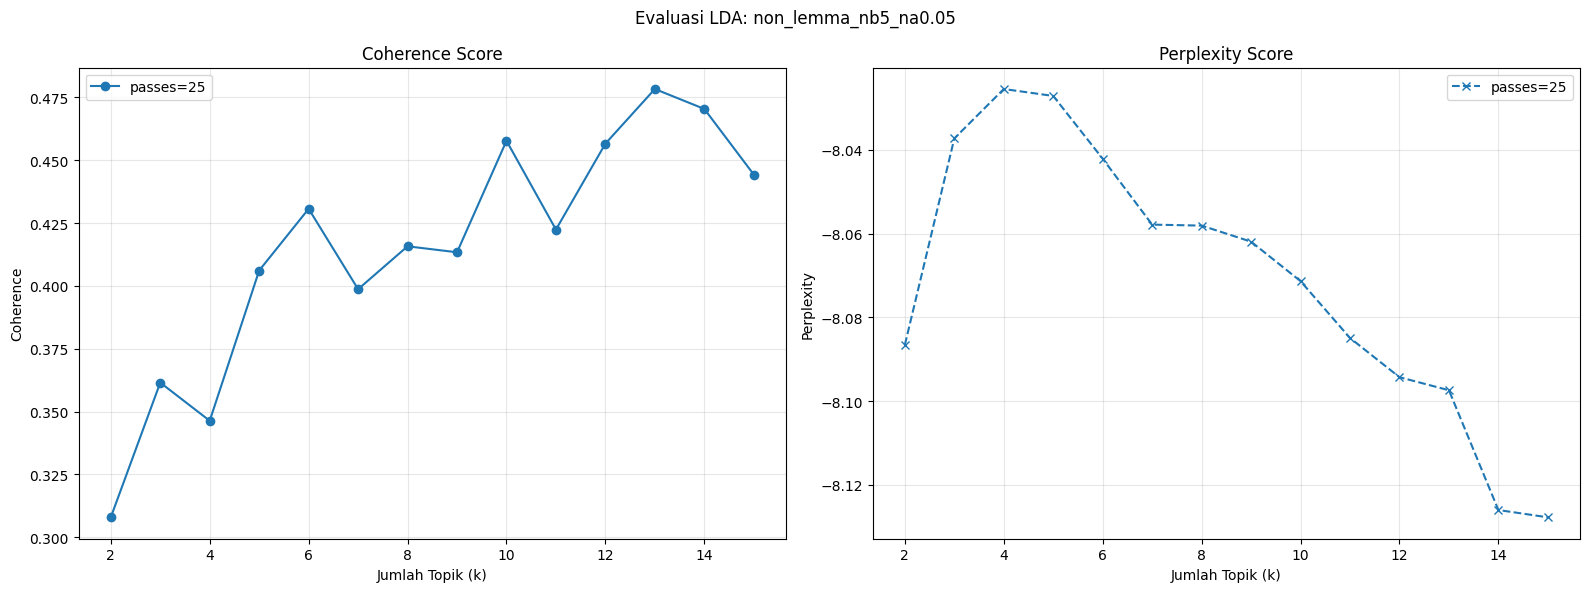


📊 Eksperimen: non_lemma_nb5_na0.6

🔁 Evaluasi passes = 25


k=2 | passes=25 | coherence=0.3711 | perplexity=-7.74


k=3 | passes=25 | coherence=0.5243 | perplexity=-7.65
k=4 | passes=25 | coherence=0.5885 | perplexity=-7.63
k=5 | passes=25 | coherence=0.6052 | perplexity=-7.60
k=6 | passes=25 | coherence=0.5935 | perplexity=-7.59
k=7 | passes=25 | coherence=0.5837 | perplexity=-7.60
k=8 | passes=25 | coherence=0.5971 | perplexity=-7.59
k=9 | passes=25 | coherence=0.5668 | perplexity=-7.60
k=10 | passes=25 | coherence=0.5912 | perplexity=-7.60
k=11 | passes=25 | coherence=0.5141 | perplexity=-7.61
k=12 | passes=25 | coherence=0.5357 | perplexity=-7.61
k=13 | passes=25 | coherence=0.5454 | perplexity=-7.62
k=14 | passes=25 | coherence=0.5617 | perplexity=-7.62
k=15 | passes=25 | coherence=0.5385 | perplexity=-7.62


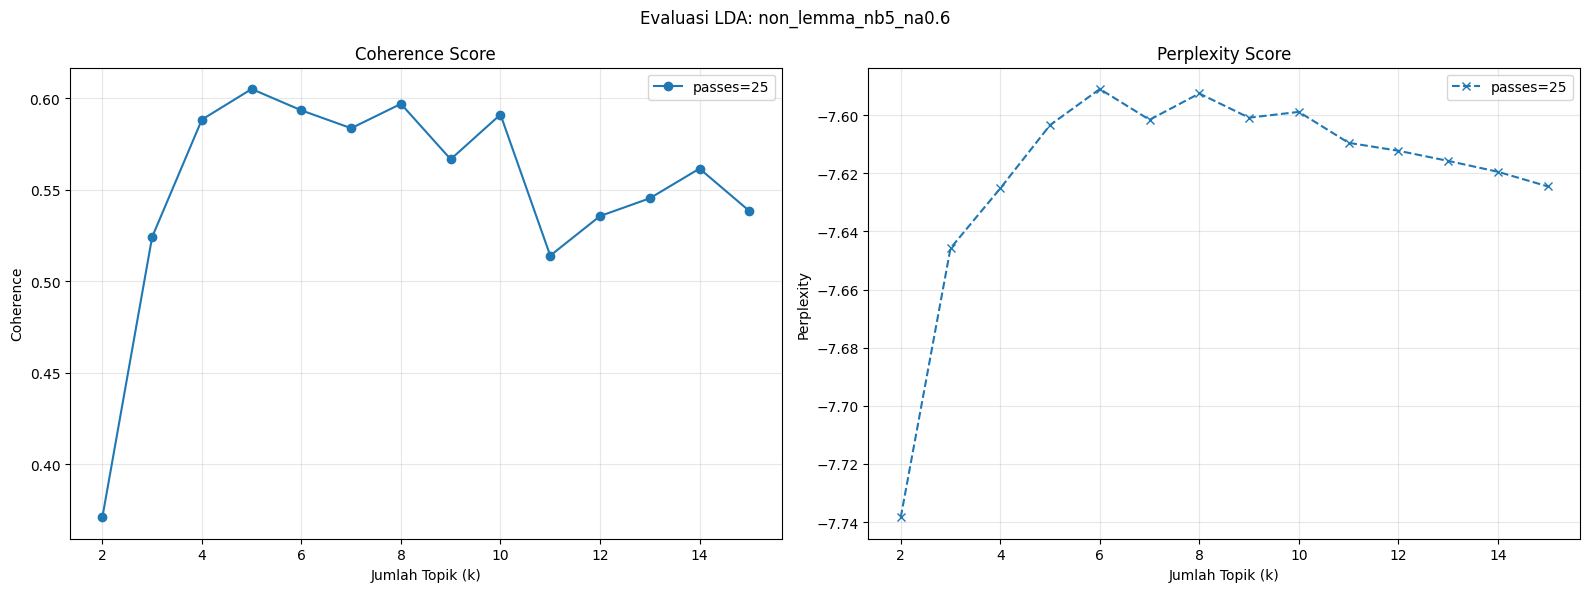

In [ ]:
passes_list = [PASSES_FINAL]

df_hasil_nonlemma = []

for label, data in gensim_nonlemma.items():
    print(f"\n📊 Eksperimen: {label}")

    df_result = evaluate_lda_multi_passes(
        corpus=data['corpus'],
        dictionary=data['dict'],
        texts=df_lda['stopword_removed'].tolist(),
        passes_list=passes_list
    )

    df_result["eksperimen"] = label
    df_result["no_below"] = data["no_below"]
    df_result["no_above"] = data["no_above"]

    df_hasil_nonlemma.append(df_result)
    plot_lda_results(df_result, label)

df_hasil_nonlemma = pd.concat(df_hasil_nonlemma).reset_index(drop=True)

In [ ]:
df_nonlemma_best = df_hasil_nonlemma.loc[
    df_hasil_nonlemma.groupby(['eksperimen', 'passes'])['coherence'].idxmax()
].reset_index(drop=True)

df_nonlemma_best = df_nonlemma_best.sort_values(
    by=["passes", "coherence"], ascending=False
).reset_index(drop=True)

print(f"Jumlah model terbaik (eksperimen x passes): {len(df_nonlemma_best)}")
display(df_nonlemma_best)

Jumlah model terbaik (eksperimen x passes): 2


,k,passes,coherence,perplexity,model,eksperimen,no_below,no_above
0,5,25,0.605171,-7.603399,"LdaModel<num_terms=6076, num_topics=5, decay=0...",non_lemma_nb5_na0.6,5,0.60
1,13,25,0.478314,-8.097389,"LdaModel<num_terms=5714, num_topics=13, decay=...",non_lemma_nb5_na0.05,5,0.05


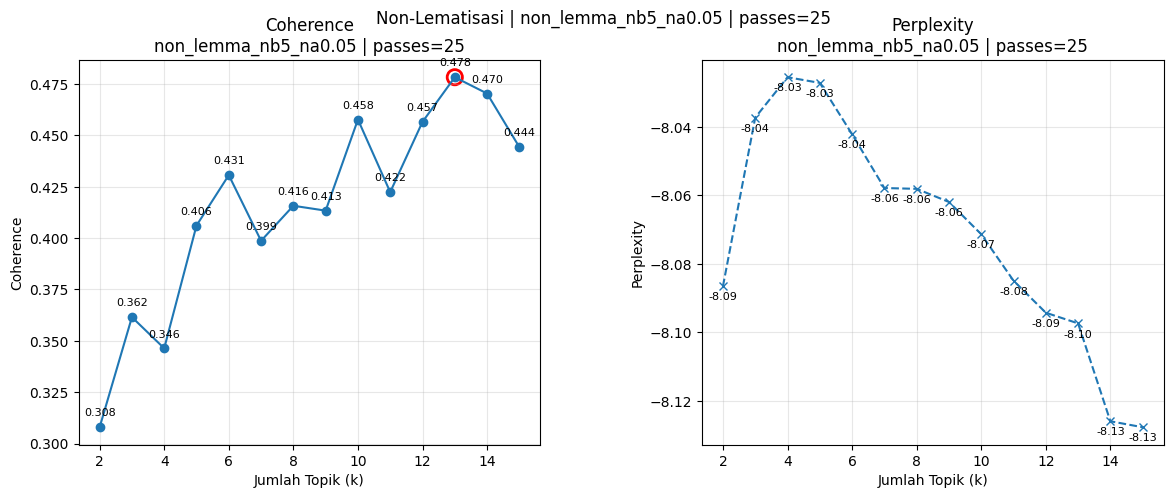

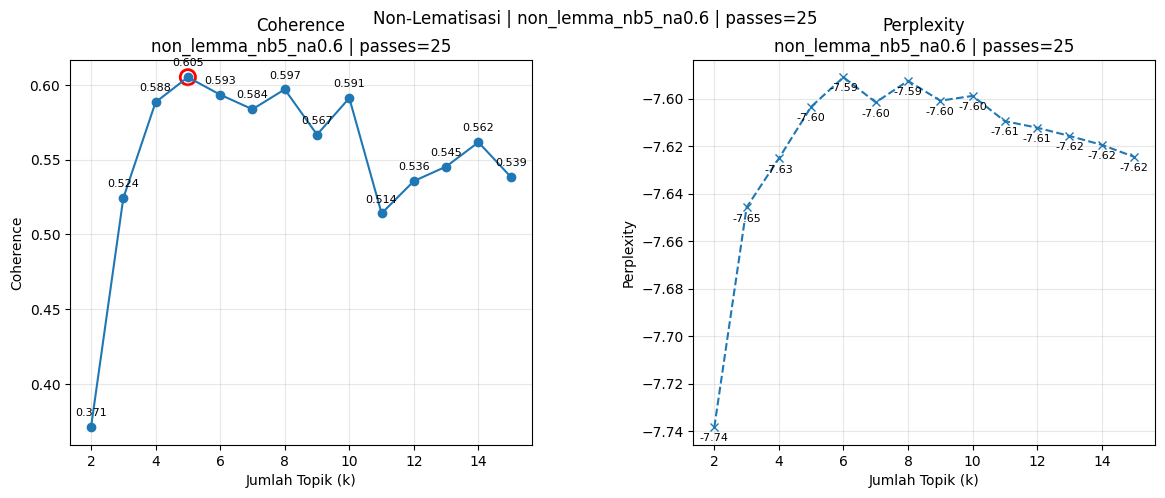

In [ ]:
plot_best_lda(df_best=df_nonlemma_best, df_all=df_hasil_nonlemma, title_prefix="Non-Lematisasi")

### 7.2 Ekstraksi Topik — Non-Lematisasi

Menampilkan kata kunci dominan dan rumus probabilitas kata untuk model terbaik pada masing-masing eksperimen Non-Lematisasi.


In [ ]:
os.makedirs("lda_results/nonlemma_topics", exist_ok=True)

for _, row in df_nonlemma_best.iterrows():
    label = row["eksperimen"]
    k = int(row["k"])
    passes = int(row["passes"])

    print(f"\n{'=' * 60}")
    print(f"  {label} | k={k} | passes={passes}")
    print(f"{'=' * 60}")

    model_row = df_hasil_nonlemma[
        (df_hasil_nonlemma["eksperimen"] == label) &
        (df_hasil_nonlemma["k"] == k) &
        (df_hasil_nonlemma["passes"] == passes)
    ]

    if model_row.empty:
        print("Model tidak ditemukan")
        continue

    lda_model = model_row.iloc[0]["model"]
    df_topic = extract_topic_info(lda_model, num_words=25)

    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.max_rows", None)
    print(df_topic[["Topik ID", "Kata Kunci Dominan", "Rumus Probabilitas"]].to_string(index=False))
    pd.reset_option("display.max_colwidth")
    pd.reset_option("display.max_rows")

    output_path = f"lda_results/nonlemma_topics/{label}_k{k}_p{passes}_topics.csv"
    df_topic.to_csv(output_path, index=False)
    print(f"\n✔ saved: {output_path}")


  non_lemma_nb5_na0.6 | k=5 | passes=25
 Topik ID                                                                                                                                                                                                                                                                           Kata Kunci Dominan                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    Rumus Probabilitas
        1                                                                     Topic, Sentiment_Analysis, Social, Media, Topics, Pu

### 7.3 Pelabelan Topik — Non-Lematisasi

Pemberian nama/label pada setiap topik berdasarkan interpretasi kata kunci dominan yang dihasilkan model.


In [ ]:
# Label topik: non_lemma_nb5_na0.6 | k=5
labels_nonlemma_nb5_na06_k5 = {
    1: "Sentiment Social Media Analytics",
    2: "AI-Driven Predictive Analytics",
    3: "Dimensionality Reduction Prediction",
    4: "Deep Learning Time Series Forecasting",
    5: "Feature Selection dan ML Classification",
}

# Label topik: non_lemma_nb5_na0.05 | k=13
labels_nonlemma_nb5_na005_k13 = {
    1:  "Image and Spectral Processing",
    2:  "BERT and Aspect-Based Sentiment",
    3:  "Education and Food Safety Policy",
    4:  "Cyber Attack and Intrusion Detection",
    5:  "Financial Market and Multimodal Prediction",
    6:  "Fault Diagnosis and Ensemble Learning",
    7:  "Energy Load and Grid Forecasting",
    8:  "IoT and Smart System Infrastructure",
    9:  "COVID-19 News and Market Analysis",
    10: "Predictive Maintenance and System Degradation",
    11: "Medical Diagnosis and Clinical AI",
    12: "Customer Review and Opinion Mining",
    13: "Smart City and Urban Infrastructure",
}


def add_labels(df_topic, label_dict):
    """Menyisipkan kolom 'Label Topik' pada dataframe hasil ekstraksi topik."""
    df = df_topic.copy()
    df.insert(1, "Label Topik", df["Topik ID"].map(label_dict))
    return df


configs_nonlemma = [
    {"eksperimen": "non_lemma_nb5_na0.6", "k": 5, "passes": 25,
     "labels": labels_nonlemma_nb5_na06_k5, "sheet": "nb5_na0.6_k5"},
    {"eksperimen": "non_lemma_nb5_na0.05", "k": 13, "passes": 25,
     "labels": labels_nonlemma_nb5_na005_k13, "sheet": "nb5_na0.05_k13"},
]

In [ ]:
os.makedirs("lda_results", exist_ok=True)
output_excel_nonlemma = "lda_results/nonlemma_topics_labeled.xlsx"

with pd.ExcelWriter(output_excel_nonlemma, engine="openpyxl") as writer:
    for cfg in configs_nonlemma:
        print(f"\n{'=' * 60}")
        print(f"{cfg['eksperimen']} | k={cfg['k']} | passes={cfg['passes']}")
        print(f"{'=' * 60}")

        model_row = df_hasil_nonlemma[
            (df_hasil_nonlemma["eksperimen"] == cfg["eksperimen"]) &
            (df_hasil_nonlemma["k"] == cfg["k"]) &
            (df_hasil_nonlemma["passes"] == cfg["passes"])
        ]

        if model_row.empty:
            print("Model tidak ditemukan.")
            continue

        lda_model = model_row.iloc[0]["model"]
        df_topic = extract_topic_info(lda_model, num_words=15)
        df_labeled = add_labels(df_topic, cfg["labels"])

        display(df_labeled[["Topik ID", "Label Topik", "Kata Kunci Dominan"]])

        df_labeled.to_excel(writer, sheet_name=cfg["sheet"], index=False)

        ws = writer.sheets[cfg["sheet"]]
        for col in ws.columns:
            max_len = max(len(str(cell.value)) if cell.value else 0 for cell in col)
            ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 60)

        print(f"✔ sheet saved: {cfg['sheet']}")

print(f"\n✅ File Excel tersimpan di:\n{output_excel_nonlemma}")


non_lemma_nb5_na0.6 | k=5 | passes=25


,Topik ID,Label Topik,Kata Kunci Dominan
0,1,Sentiment Social Media Analytics,"Topic, Sentiment_Analysis, Social, Media, Topi..."
1,2,AI-Driven Predictive Analytics,"Ai, Predictive, Analytics, Systems, Management..."
2,3,Dimensionality Reduction Prediction,"Prediction, Reduction, Dimensionality, High, A..."
3,4,Deep Learning Time Series Forecasting,"Models, Forecasting, Series, Long_Short_Term_M..."
4,5,Feature Selection dan ML Classification,"Features, Classification, Accuracy, Selection,..."


✔ sheet saved: nb5_na0.6_k5

non_lemma_nb5_na0.05 | k=13 | passes=25


,Topik ID,Label Topik,Kata Kunci Dominan
0,1,Image and Spectral Processing,"Spatial, Spectral, Fuzzy, Hyperspectral, Matri..."
1,2,BERT and Aspect-Based Sentiment,"D_, Aspect, Graph, Arabic, Bert, Texts, Fine, ..."
2,3,Education and Food Safety Policy,"Food, Education, Students, Policy, Business, A..."
3,4,Cyber Attack and Intrusion Detection,"Attacks, Water, Intrusion, Attack, Traffic, Id..."
4,5,Financial Market and Multimodal Prediction,"Financial, Multimodal, Modal, Market, Stock, C..."
5,6,Fault Diagnosis and Ensemble Learning,"Fault, Rf, Gradient, Boosting, Diagnosis, Xgbo..."
6,7,Energy Load and Grid Forecasting,"Load, Consumption, Grid, Traffic, Mae, Rmse, E..."
7,8,IoT and Smart System Infrastructure,"Iot, Cloud, Supply, Devices, Computing, Chain,..."
8,9,COVID-19 News and Market Analysis,"Covid, News, Pandemic, Tweets, C, Stock, Polit..."
9,10,Predictive Maintenance and System Degradation,"Gas, Project, Life, Maintenance, Construction,..."


✔ sheet saved: nb5_na0.05_k13

✅ File Excel tersimpan di:
lda_results/nonlemma_topics_labeled.xlsx


### 7.3b Visualisasi Distribusi Kata per Topik — Non-Lematisasi

Untuk tiap skenario Non-Lematisasi, dibuat dua visualisasi dengan Top-N kata yang **sama**: (a) probabilitas LDA, dan (b) frekuensi kemunculan kata di corpus — supaya bisa dibandingkan apakah kata yang bobotnya tinggi di LDA juga sering muncul di corpus.


non_lemma_nb5_na0.6 | k=5 | passes=25


,Topik,Nama Topik,Kata Dominan
0,1,Sentiment Social Media Analytics,"topic, sentiment_analysis, social, media, topi..."
1,2,AI-Driven Predictive Analytics,"ai, predictive, analytics, systems, management..."
2,3,Dimensionality Reduction Prediction,"prediction, reduction, dimensionality, high, a..."
3,4,Deep Learning Time Series Forecasting,"models, forecasting, series, long_short_term_m..."
4,5,Feature Selection dan ML Classification,"features, classification, accuracy, selection,..."


✔ Visualisasi disimpan: lda_results/topic_visualizations/non_lemma_nb5_na0.6_k5_topic_word_probability.png


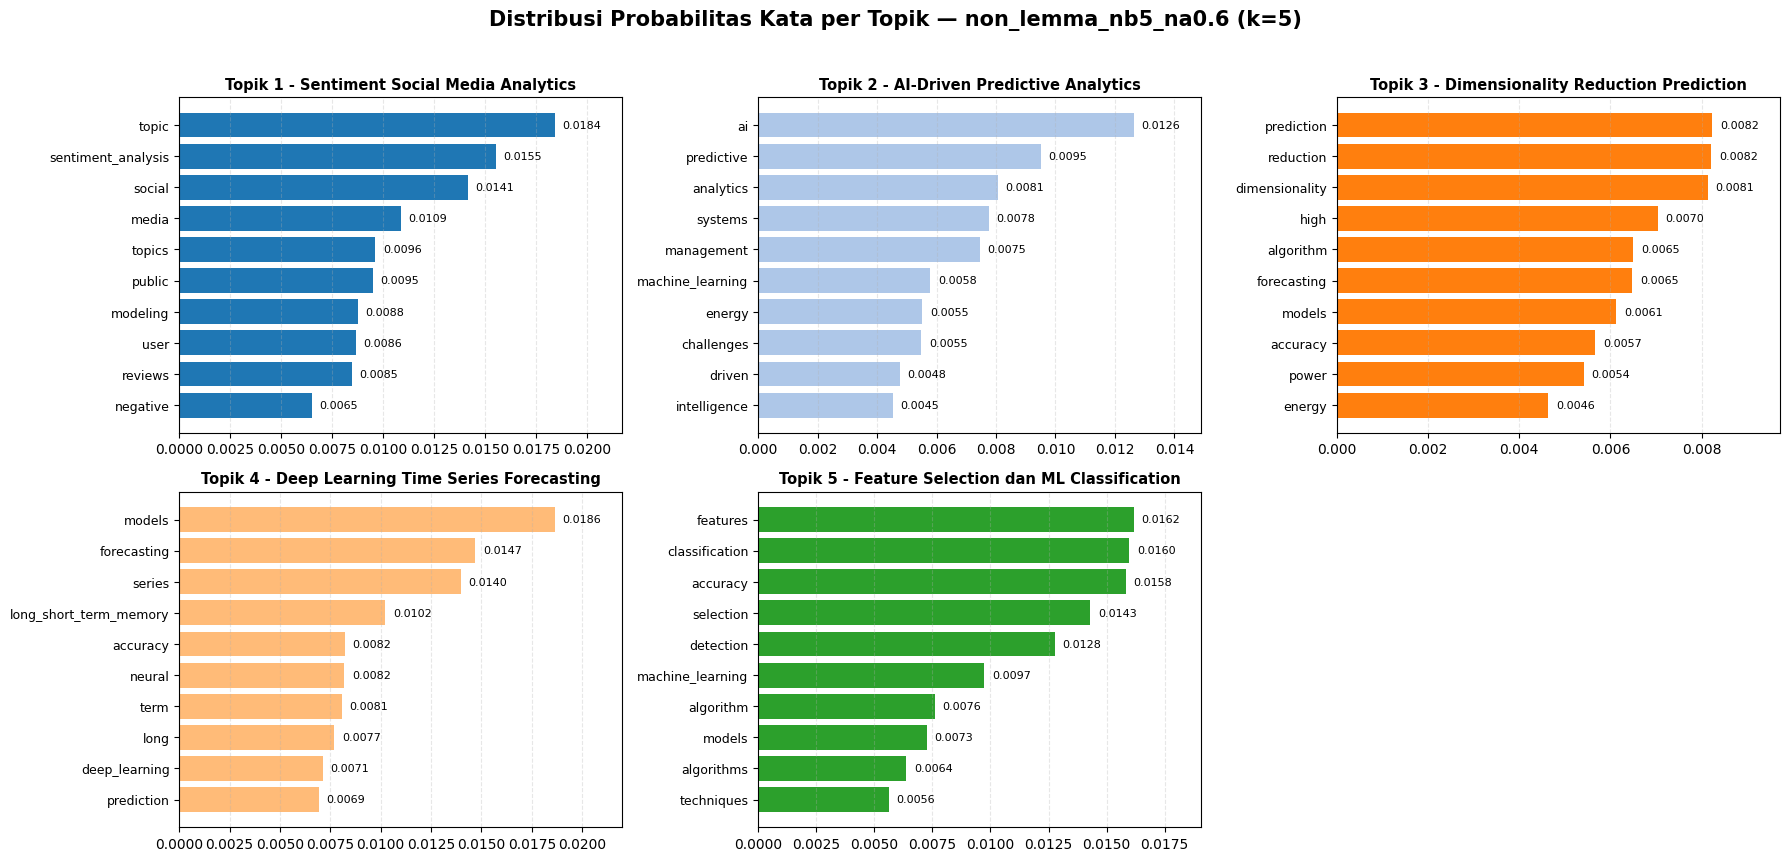

✔ Visualisasi disimpan: lda_results/topic_visualizations/non_lemma_nb5_na0.6_k5_topic_word_frequency.png


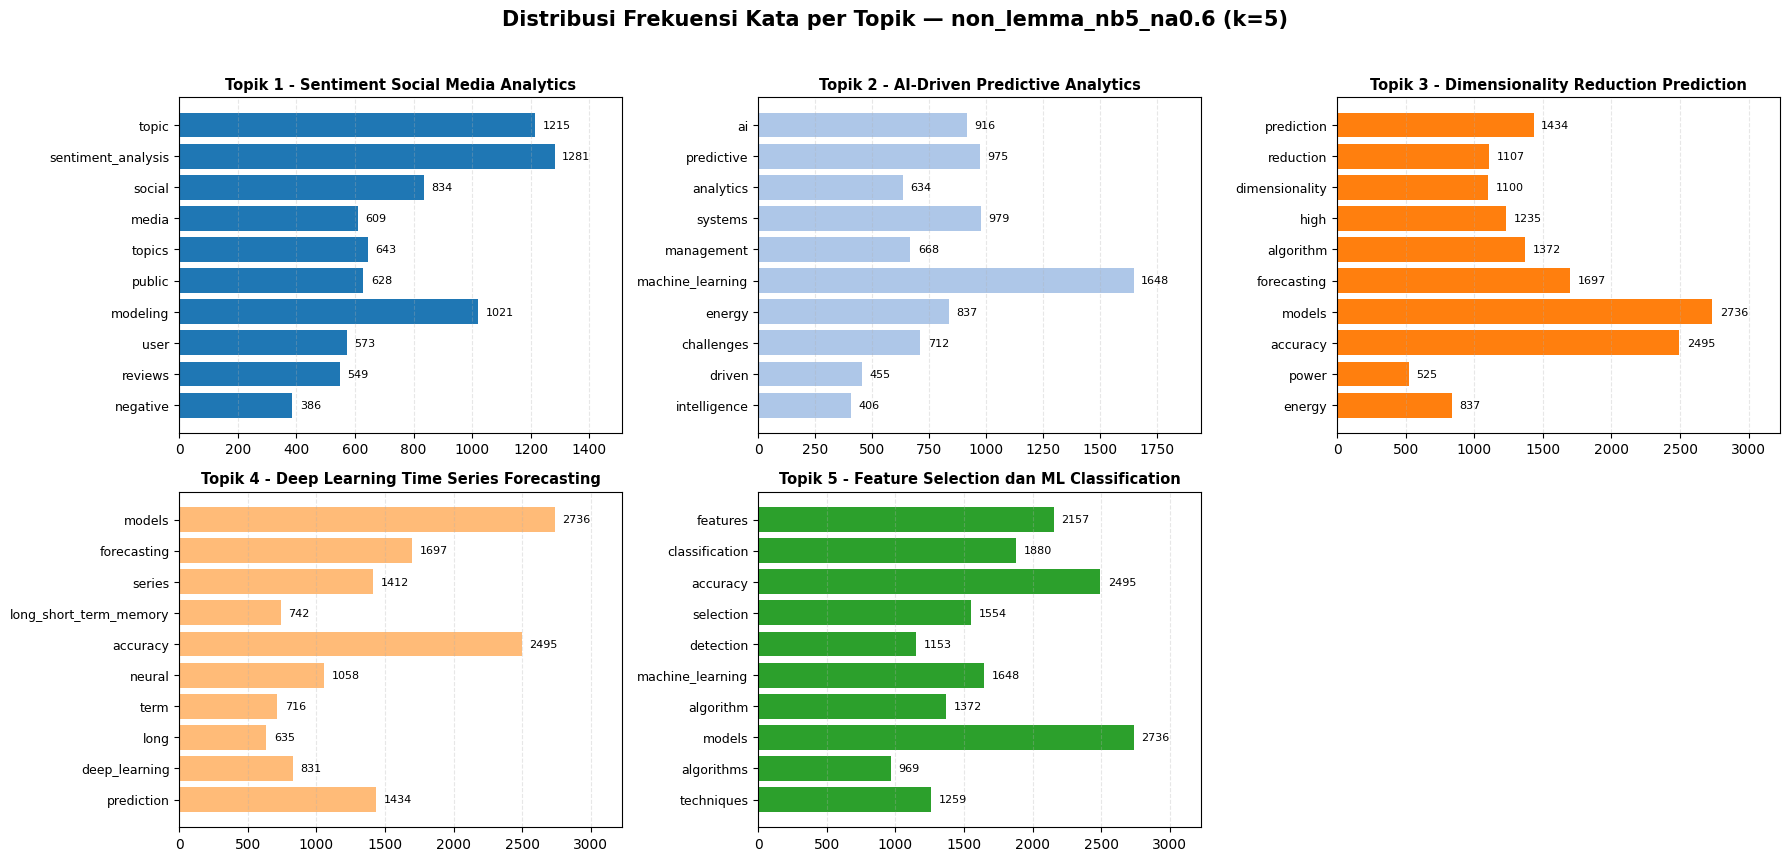


non_lemma_nb5_na0.05 | k=13 | passes=25


,Topik,Nama Topik,Kata Dominan
0,1,Image and Spectral Processing,"spatial, spectral, fuzzy, hyperspectral, matri..."
1,2,BERT and Aspect-Based Sentiment,"d_, aspect, graph, arabic, bert, texts, fine, ..."
2,3,Education and Food Safety Policy,"food, education, students, policy, business, a..."
3,4,Cyber Attack and Intrusion Detection,"attacks, water, intrusion, attack, traffic, id..."
4,5,Financial Market and Multimodal Prediction,"financial, multimodal, modal, market, stock, c..."
5,6,Fault Diagnosis and Ensemble Learning,"fault, rf, gradient, boosting, diagnosis, xgbo..."
6,7,Energy Load and Grid Forecasting,"load, consumption, grid, traffic, mae, rmse, e..."
7,8,IoT and Smart System Infrastructure,"iot, cloud, supply, devices, computing, chain,..."
8,9,COVID-19 News and Market Analysis,"covid, news, pandemic, tweets, c, stock, polit..."
9,10,Predictive Maintenance and System Degradation,"gas, project, life, maintenance, construction,..."


✔ Visualisasi disimpan: lda_results/topic_visualizations/non_lemma_nb5_na0.05_k13_topic_word_probability.png


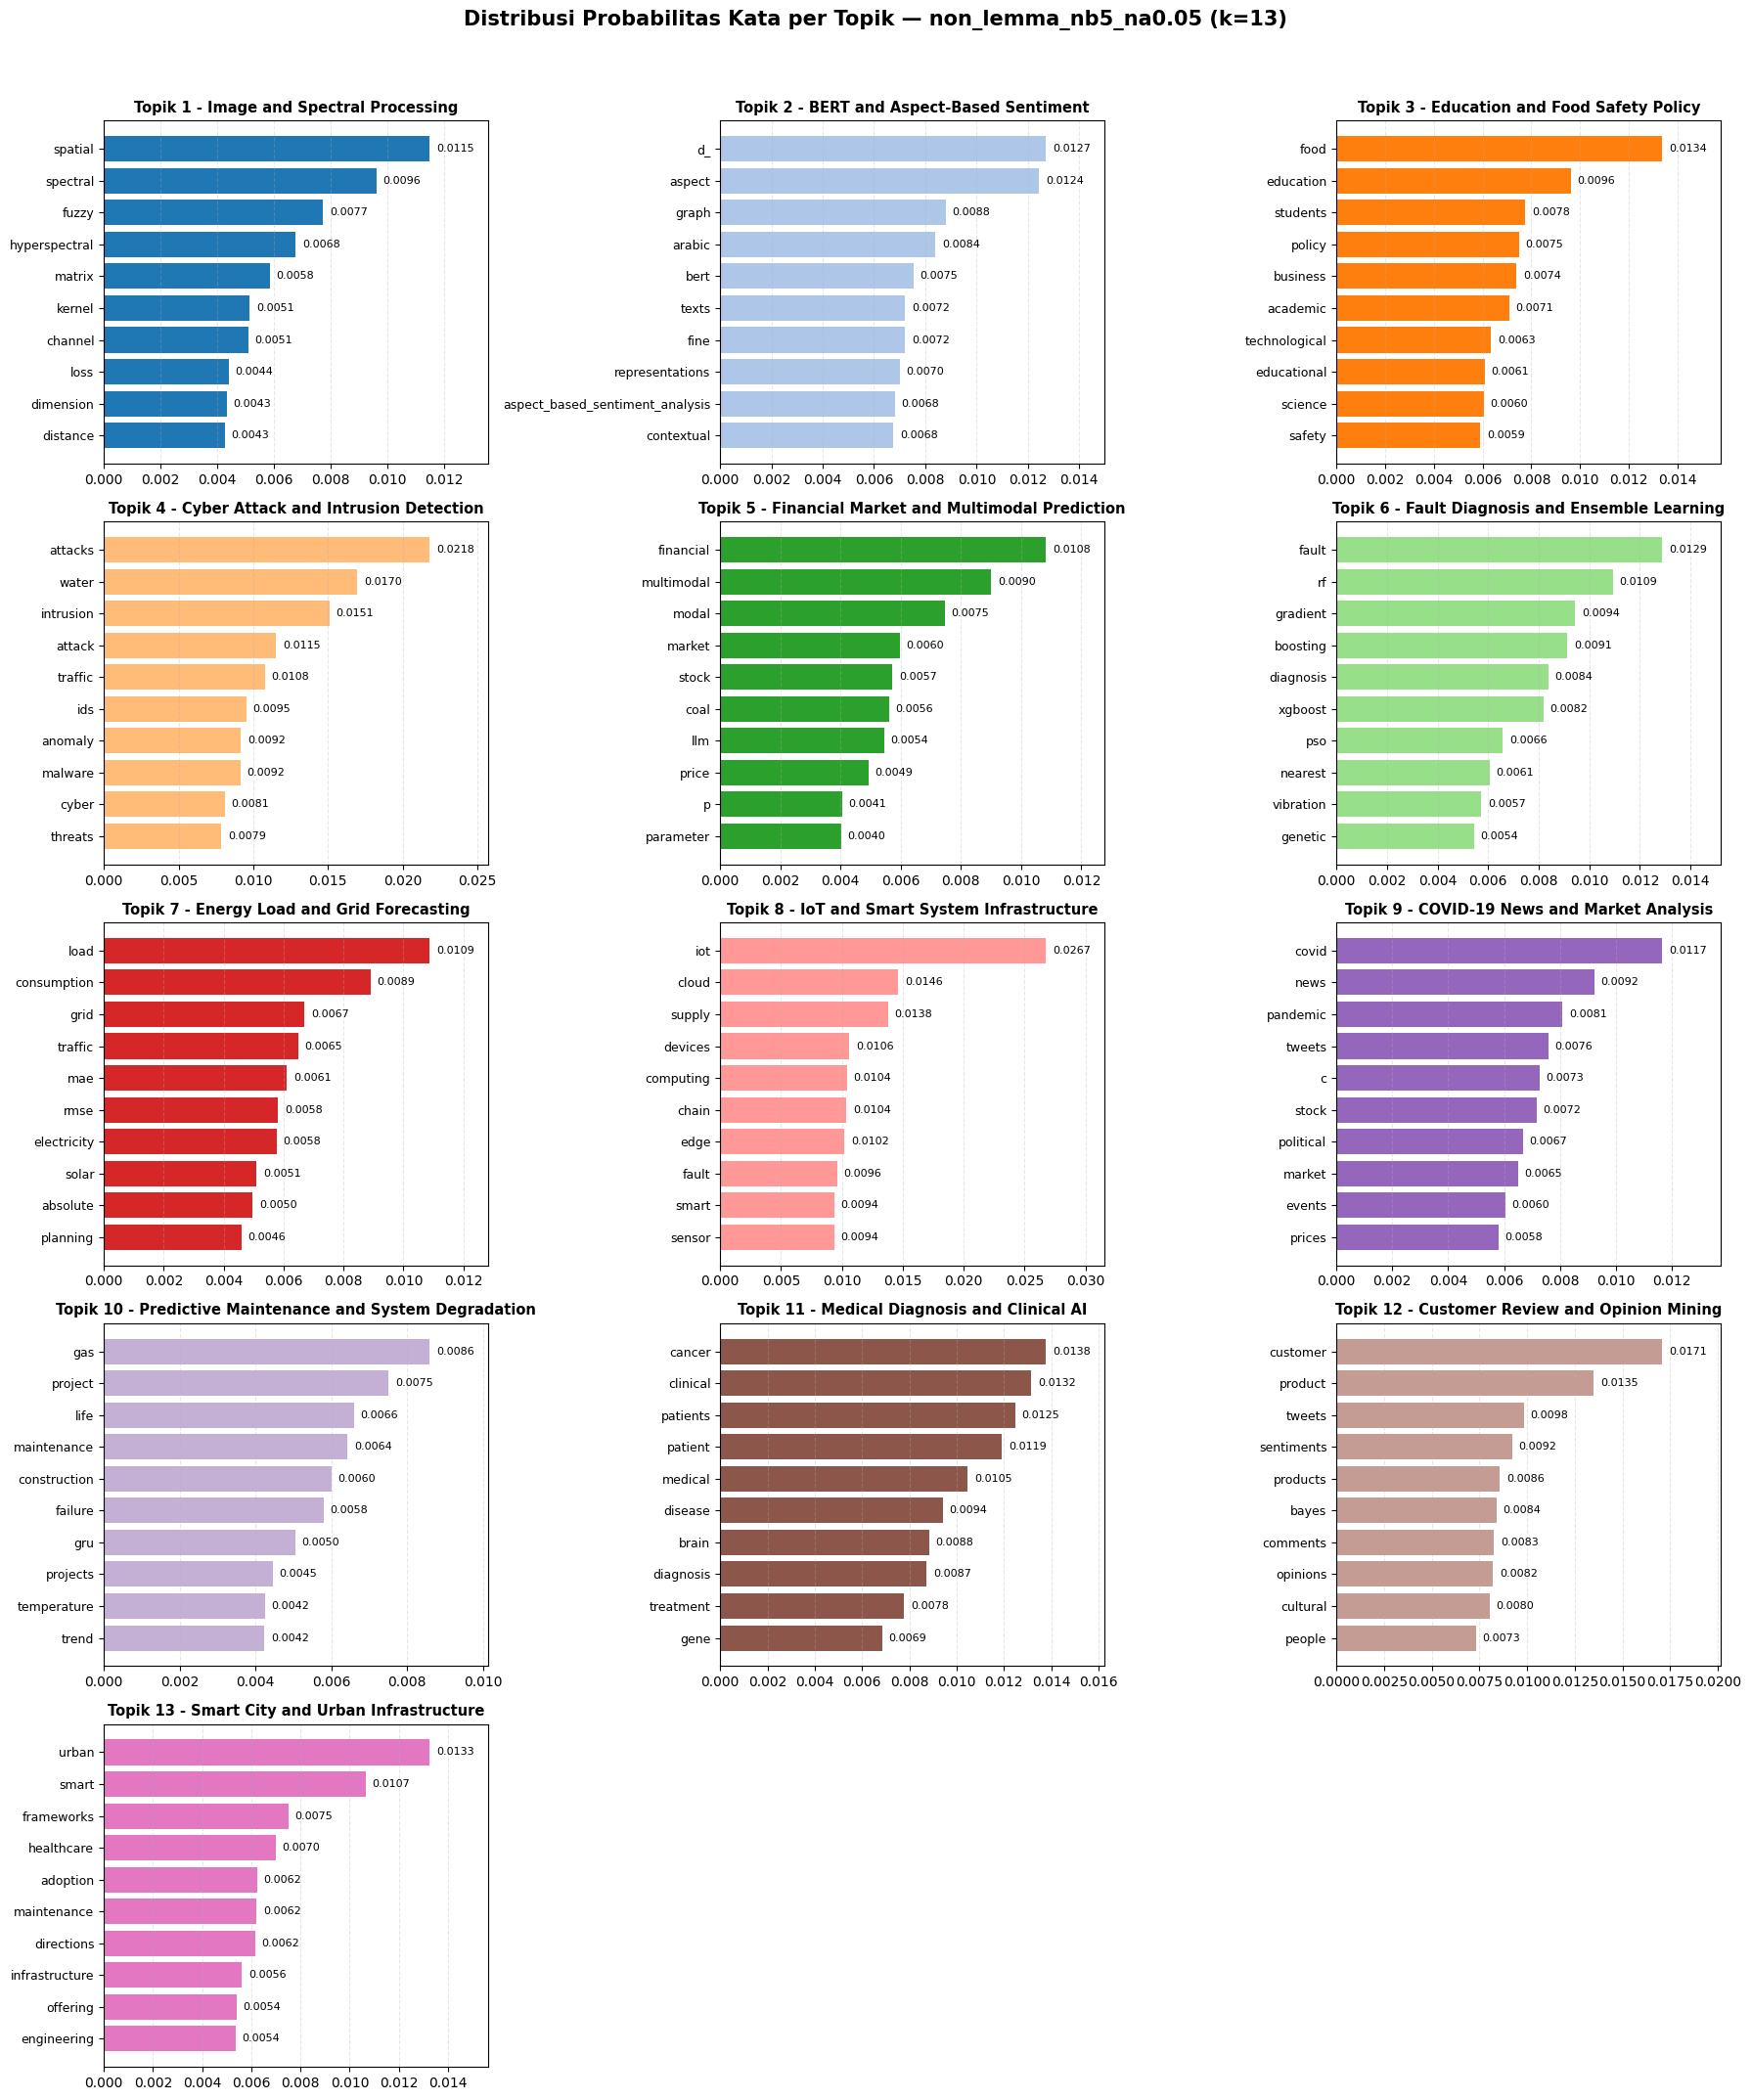

✔ Visualisasi disimpan: lda_results/topic_visualizations/non_lemma_nb5_na0.05_k13_topic_word_frequency.png


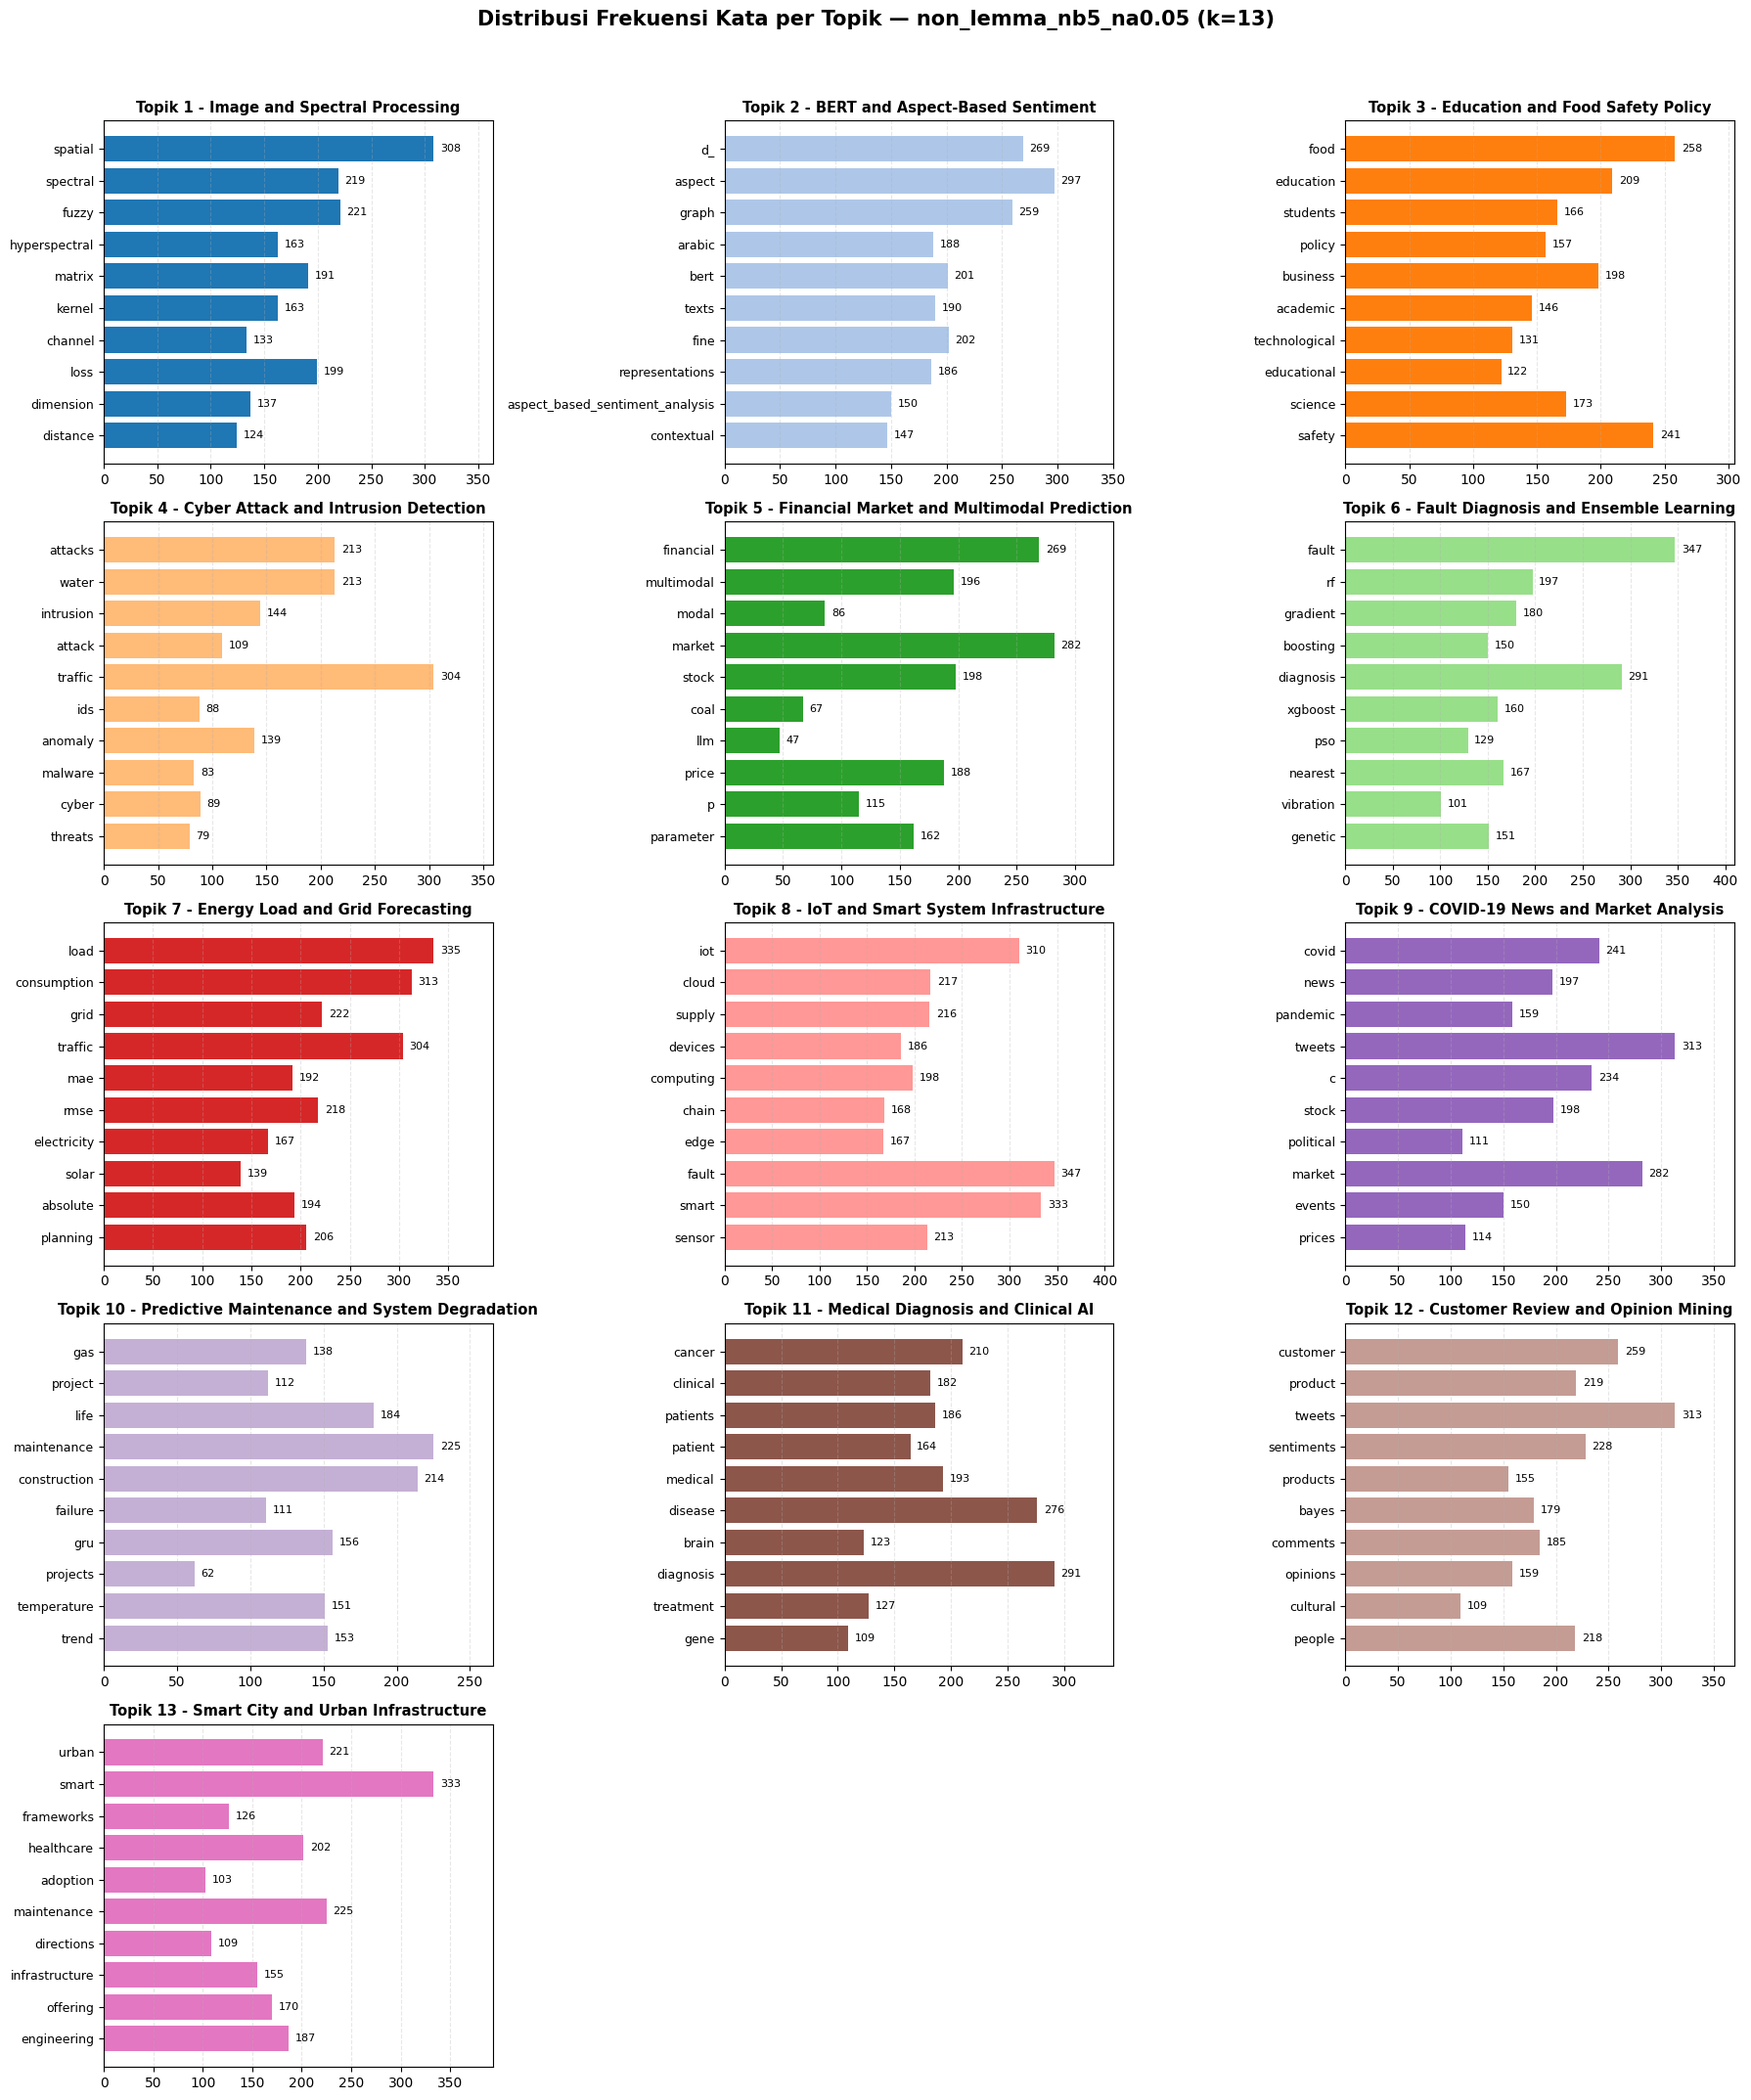

In [ ]:
TOP_N_WORDS = 10

for cfg in configs_nonlemma:
    label = cfg["eksperimen"]
    k = cfg["k"]
    passes = cfg["passes"]
    topic_labels = cfg["labels"]

    model_row = df_hasil_nonlemma[
        (df_hasil_nonlemma["eksperimen"] == label) &
        (df_hasil_nonlemma["k"] == k) &
        (df_hasil_nonlemma["passes"] == passes)
    ]
    if model_row.empty:
        print(f"Model tidak ditemukan untuk {label}")
        continue

    lda_model = model_row.iloc[0]["model"]

    top_words = get_top_words_per_topic(lda_model, num_words=TOP_N_WORDS)
    word_freq = get_topic_word_frequency(top_words, texts_nonlemma)

    print(f"\n{'=' * 60}\n{label} | k={k} | passes={passes}\n{'=' * 60}")

    df_summary = create_topic_summary_table(top_words, topic_labels, num_words=TOP_N_WORDS)
    display(df_summary)

    fig_prob = plot_topic_word_distribution(
        top_words, topic_labels, value_type="probability",
        suptitle=f"Distribusi Probabilitas Kata per Topik — {label} (k={k})"
    )
    save_topic_visualization(fig_prob, f"{label}_k{k}_topic_word_probability.png")
    plt.show()

    fig_freq = plot_topic_word_distribution(
        word_freq, topic_labels, value_type="frequency",
        suptitle=f"Distribusi Frekuensi Kata per Topik — {label} (k={k})"
    )
    save_topic_visualization(fig_freq, f"{label}_k{k}_topic_word_frequency.png")
    plt.show()


### 7.4 Penggabungan Hasil Topik ke Dataset — Non-Lematisasi

Menggabungkan distribusi probabilitas topik dan label topik dominan ke dalam dataset abstrak asli, untuk masing-masing eksperimen terbaik.


In [ ]:
configs_nonlemma_full = [
    {"eksperimen": "non_lemma_nb5_na0.6", "k": 5, "passes": 25, "labels": labels_nonlemma_nb5_na06_k5},
    {"eksperimen": "non_lemma_nb5_na0.05", "k": 13, "passes": 25, "labels": labels_nonlemma_nb5_na005_k13},
]

os.makedirs("lda_dataset/nonlemma", exist_ok=True)

for cfg in configs_nonlemma_full:
    print(f"\nMemproses {cfg['eksperimen']}")

    model_row = df_hasil_nonlemma[
        (df_hasil_nonlemma["eksperimen"] == cfg["eksperimen"]) &
        (df_hasil_nonlemma["k"] == cfg["k"]) &
        (df_hasil_nonlemma["passes"] == cfg["passes"])
    ]

    if model_row.empty:
        print("Model tidak ditemukan")
        continue

    lda_model = model_row.iloc[0]["model"]
    corpus = gensim_nonlemma[cfg["eksperimen"]]["corpus"]
    k = cfg["k"]

    topic_vectors, dominant_topics = get_topic_distribution_full(lda_model, corpus, k)

    df_final = df_lda.copy()
    df_final = df_final.rename(columns={"stopword_removed": "non_lemmatization"})
    df_final = df_final[["Year", "clean_text", "non_lemmatization"]]

    for i in range(k):
        df_final[f"topic_{i + 1}"] = topic_vectors[:, i]

    df_final["topik_dominan"] = [x[0] for x in dominant_topics]
    df_final["probabilitas_topik"] = [x[1] for x in dominant_topics]
    df_final["label_topik"] = df_final["topik_dominan"].map(cfg["labels"])

    output_path = f"lda_dataset/nonlemma/{cfg['eksperimen']}_k{cfg['k']}_p{cfg['passes']}.csv"
    df_final.to_csv(output_path, index=False)

    print(f"✔ saved: {output_path}")
    display(df_final.tail())


Memproses non_lemma_nb5_na0.6
✔ saved: lda_dataset/nonlemma/non_lemma_nb5_na0.6_k5_p25.csv


,Year,clean_text,non_lemmatization,topic_1,topic_2,topic_3,topic_4,topic_5,topik_dominan,probabilitas_topik,label_topik
3321,2026,this debate examines how climate change presen...,"[debate, examines, climate, presents, complex,...",0.071865,0.807588,0.119168,0.000680,0.000699,2,0.807588,AI-Driven Predictive Analytics
3322,2026,the current literature on electrical maintenan...,"[current, literature, electrical, maintenance,...",0.000530,0.997370,0.000739,0.000671,0.000690,2,0.997370,AI-Driven Predictive Analytics
3323,2026,this proposes a hybrid automated machine_learn...,"[hybrid, automated, machine_learning, automl, ...",0.000613,0.370672,0.000854,0.092575,0.535286,5,0.535286,Feature Selection dan ML Classification
3324,2026,the rapid expansion of artificial intelligence...,"[rapid, expansion, artificial, intelligence, a...",0.000554,0.997253,0.000772,0.000701,0.000720,2,0.997253,AI-Driven Predictive Analytics
3325,2026,traditional nursing practices often rely on em...,"[traditional, nursing, practices, often, rely,...",0.000814,0.632490,0.052972,0.159341,0.154383,2,0.632490,AI-Driven Predictive Analytics



Memproses non_lemma_nb5_na0.05
✔ saved: lda_dataset/nonlemma/non_lemma_nb5_na0.05_k13_p25.csv


,Year,clean_text,non_lemmatization,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topik_dominan,probabilitas_topik,label_topik
3321,2026,this debate examines how climate change presen...,"[debate, examines, climate, presents, complex,...",0.000921,0.041842,0.431327,0.000491,0.017339,0.000759,0.203054,0.000559,0.173071,0.070903,0.000586,0.000616,0.058530,3,0.431327,Education and Food Safety Policy
3322,2026,the current literature on electrical maintenan...,"[current, literature, electrical, maintenance,...",0.001233,0.017952,0.182675,0.000657,0.000721,0.001016,0.111397,0.148035,0.000915,0.024274,0.000785,0.073343,0.436997,13,0.436997,Smart City and Urban Infrastructure
3323,2026,this proposes a hybrid automated machine_learn...,"[hybrid, automated, machine_learning, automl, ...",0.001551,0.001397,0.001341,0.127960,0.019642,0.508367,0.191976,0.000943,0.001152,0.001060,0.000988,0.001039,0.142585,6,0.508367,Fault Diagnosis and Ensemble Learning
3324,2026,the rapid expansion of artificial intelligence...,"[rapid, expansion, artificial, intelligence, a...",0.001358,0.001223,0.490587,0.000725,0.000795,0.018312,0.158200,0.000826,0.001008,0.000928,0.000865,0.077064,0.248108,3,0.490587,Education and Food Safety Policy
3325,2026,traditional nursing practices often rely on em...,"[traditional, nursing, practices, often, rely,...",0.001897,0.001707,0.173544,0.130808,0.001110,0.001563,0.303119,0.001152,0.073274,0.001295,0.249654,0.001269,0.059608,7,0.303119,Energy Load and Grid Forecasting


### 7.5 Visualisasi Interaktif Topik — Non-Lematisasi (pyLDAvis)

`pyLDAvis` menampilkan visualisasi interaktif untuk melihat seberapa terpisah dan koheren topik-topik yang dihasilkan model.


In [ ]:
os.makedirs("lda_vis/nonlemma", exist_ok=True)

for _, row in df_nonlemma_best.iterrows():
    label = row["eksperimen"]
    k = int(row["k"])
    passes = int(row["passes"])

    model_row = df_hasil_nonlemma[
        (df_hasil_nonlemma["eksperimen"] == label) &
        (df_hasil_nonlemma["k"] == k) &
        (df_hasil_nonlemma["passes"] == passes)
    ]

    if model_row.empty:
        continue

    lda_model = model_row.iloc[0]["model"]
    corpus = gensim_nonlemma[label]["corpus"]
    dictionary = gensim_nonlemma[label]["dict"]

    vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)

    display(HTML(f"<h3>{label} | k={k} | passes={passes}</h3>"))
    display(pyLDAvis.display(vis))

## 8. Hyperparameter Tuning — Skenario Lematisasi

Langkah yang sama seperti skenario Non-Lematisasi, kini diterapkan pada skenario **Lematisasi**.



📊 Eksperimen: lemma_nb5_na0.05

🔁 Evaluasi passes = 25


k=2 | passes=25 | coherence=0.3384 | perplexity=-7.96
k=3 | passes=25 | coherence=0.3757 | perplexity=-7.89
k=4 | passes=25 | coherence=0.3487 | perplexity=-7.87
k=5 | passes=25 | coherence=0.3222 | perplexity=-7.88
k=6 | passes=25 | coherence=0.4012 | perplexity=-7.88
k=7 | passes=25 | coherence=0.3752 | perplexity=-7.89
k=8 | passes=25 | coherence=0.4257 | perplexity=-7.90
k=9 | passes=25 | coherence=0.3956 | perplexity=-7.92
k=10 | passes=25 | coherence=0.4084 | perplexity=-7.92
k=11 | passes=25 | coherence=0.4399 | perplexity=-7.92
k=12 | passes=25 | coherence=0.4055 | perplexity=-7.94
k=13 | passes=25 | coherence=0.3883 | perplexity=-7.95
k=14 | passes=25 | coherence=0.3742 | perplexity=-7.98
k=15 | passes=25 | coherence=0.4350 | perplexity=-7.98


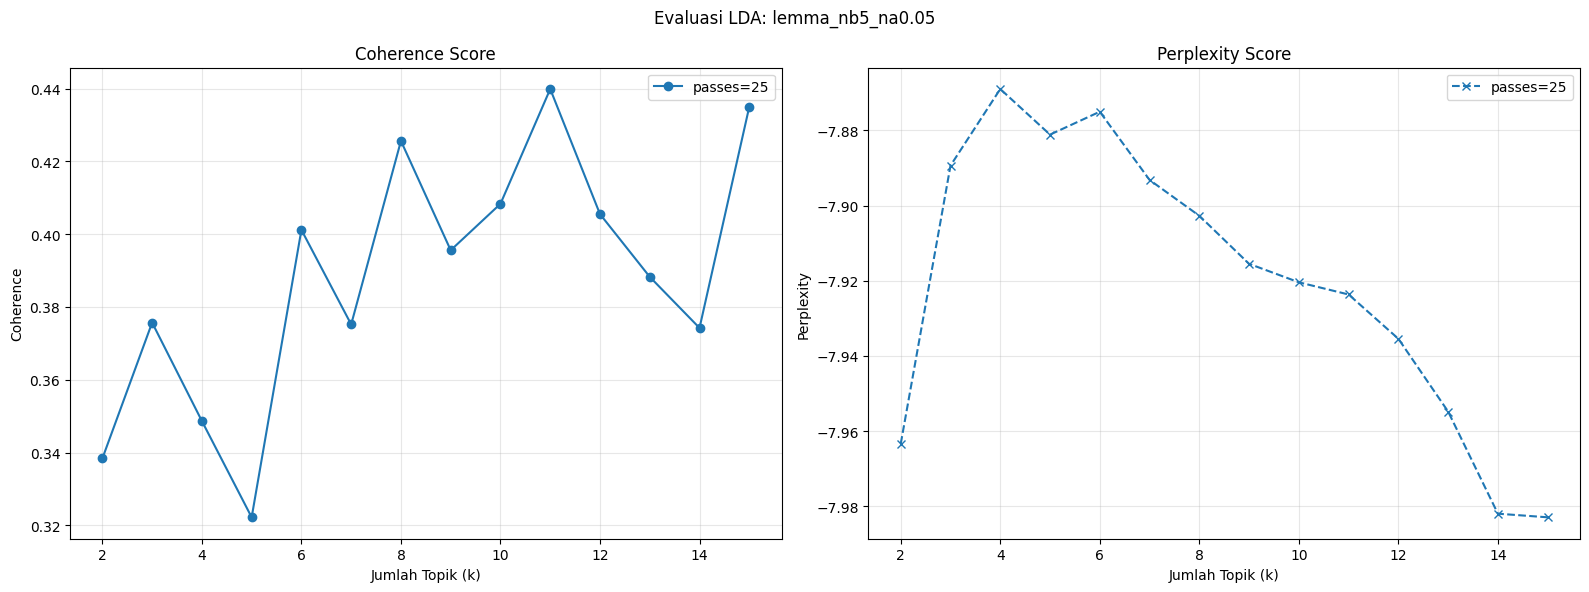


📊 Eksperimen: lemma_nb5_na0.6

🔁 Evaluasi passes = 25


k=2 | passes=25 | coherence=0.4181 | perplexity=-7.54


k=3 | passes=25 | coherence=0.5262 | perplexity=-7.48
k=4 | passes=25 | coherence=0.6212 | perplexity=-7.45
k=5 | passes=25 | coherence=0.5723 | perplexity=-7.44
k=6 | passes=25 | coherence=0.5671 | perplexity=-7.43
k=7 | passes=25 | coherence=0.5890 | perplexity=-7.43
k=8 | passes=25 | coherence=0.5715 | perplexity=-7.43
k=9 | passes=25 | coherence=0.5696 | perplexity=-7.43
k=10 | passes=25 | coherence=0.5566 | perplexity=-7.44
k=11 | passes=25 | coherence=0.5574 | perplexity=-7.43
k=12 | passes=25 | coherence=0.5397 | perplexity=-7.44
k=13 | passes=25 | coherence=0.5488 | perplexity=-7.45
k=14 | passes=25 | coherence=0.5446 | perplexity=-7.45
k=15 | passes=25 | coherence=0.5472 | perplexity=-7.45


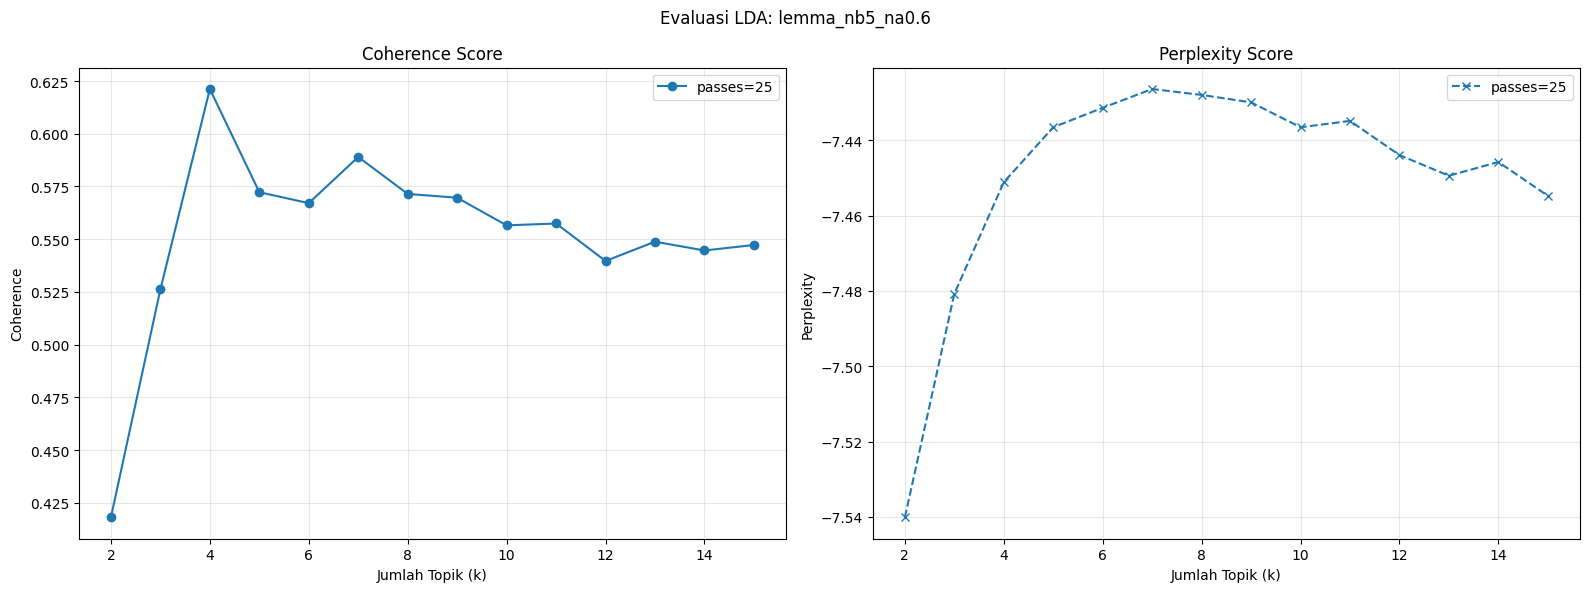

Jumlah baris hasil evaluasi: 28


,eksperimen,passes,k,coherence,perplexity,jumlah_vocab,no_below,no_above
0,lemma_nb5_na0.6,25,4,0.621200,-7.451118,5383,5,0.60
1,lemma_nb5_na0.6,25,7,0.588988,-7.426359,5383,5,0.60
2,lemma_nb5_na0.6,25,5,0.572274,-7.436521,5383,5,0.60
3,lemma_nb5_na0.6,25,8,0.571451,-7.427929,5383,5,0.60
4,lemma_nb5_na0.6,25,9,0.569645,-7.429910,5383,5,0.60
5,lemma_nb5_na0.6,25,6,0.567073,-7.431346,5383,5,0.60
6,lemma_nb5_na0.6,25,11,0.557427,-7.434831,5383,5,0.60
7,lemma_nb5_na0.6,25,10,0.556552,-7.436511,5383,5,0.60
8,lemma_nb5_na0.6,25,13,0.548807,-7.449392,5383,5,0.60
9,lemma_nb5_na0.6,25,15,0.547237,-7.454728,5383,5,0.60


In [ ]:
df_hasil_lemma = []

for label, data in gensim_lemma.items():
    print(f"\n📊 Eksperimen: {label}")

    df_result = evaluate_lda_multi_passes(
        corpus=data['corpus'],
        dictionary=data['dict'],
        texts=df_lda['lemmatization'].tolist(),
        passes_list=passes_list
    )

    df_result["eksperimen"] = label
    df_result["no_below"] = data["no_below"]
    df_result["no_above"] = data["no_above"]

    df_hasil_lemma.append(df_result)
    plot_lda_results(df_result, label)

df_hasil_lemma = pd.concat(df_hasil_lemma, ignore_index=True)
df_hasil_lemma["jumlah_vocab"] = df_hasil_lemma["eksperimen"].map(lambda x: len(gensim_lemma[x]["dict"]))

print(f"Jumlah baris hasil evaluasi: {len(df_hasil_lemma)}")
display(
    df_hasil_lemma[["eksperimen", "passes", "k", "coherence", "perplexity",
                     "jumlah_vocab", "no_below", "no_above"]]
    .sort_values(by="coherence", ascending=False)
    .reset_index(drop=True)
)

In [ ]:
df_lemma_best = df_hasil_lemma.loc[
    df_hasil_lemma.groupby(['eksperimen', 'passes'])['coherence'].idxmax()
].reset_index(drop=True)

df_lemma_best = df_lemma_best.sort_values(
    by=["passes", "coherence"], ascending=False
).reset_index(drop=True)

print(f"Jumlah model terbaik (eksperimen x passes): {len(df_lemma_best)}")
display(df_lemma_best)

Jumlah model terbaik (eksperimen x passes): 2


,k,passes,coherence,perplexity,model,eksperimen,no_below,no_above,jumlah_vocab
0,4,25,0.621200,-7.451118,"LdaModel<num_terms=5383, num_topics=4, decay=0...",lemma_nb5_na0.6,5,0.60,5383
1,11,25,0.439922,-7.923677,"LdaModel<num_terms=5003, num_topics=11, decay=...",lemma_nb5_na0.05,5,0.05,5003


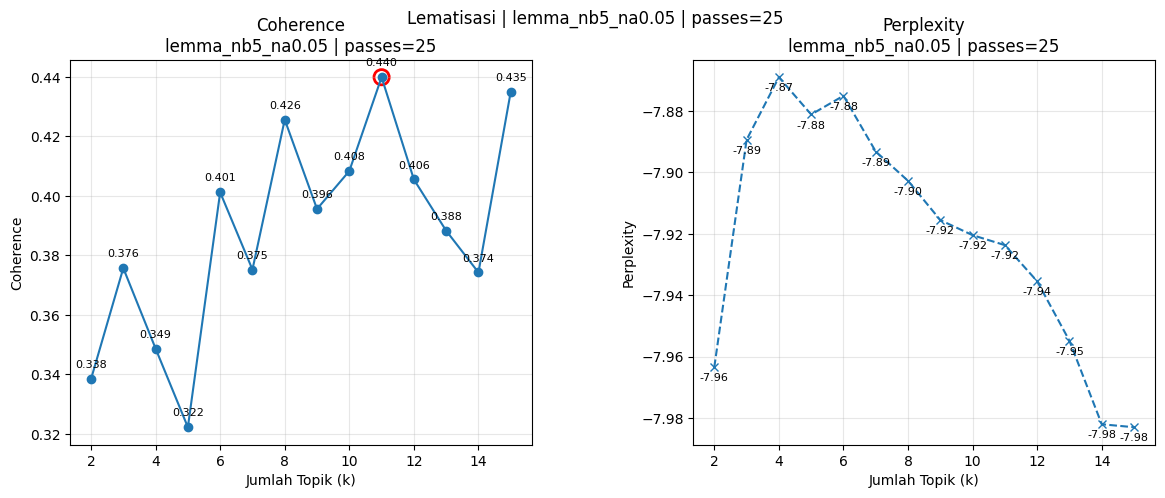

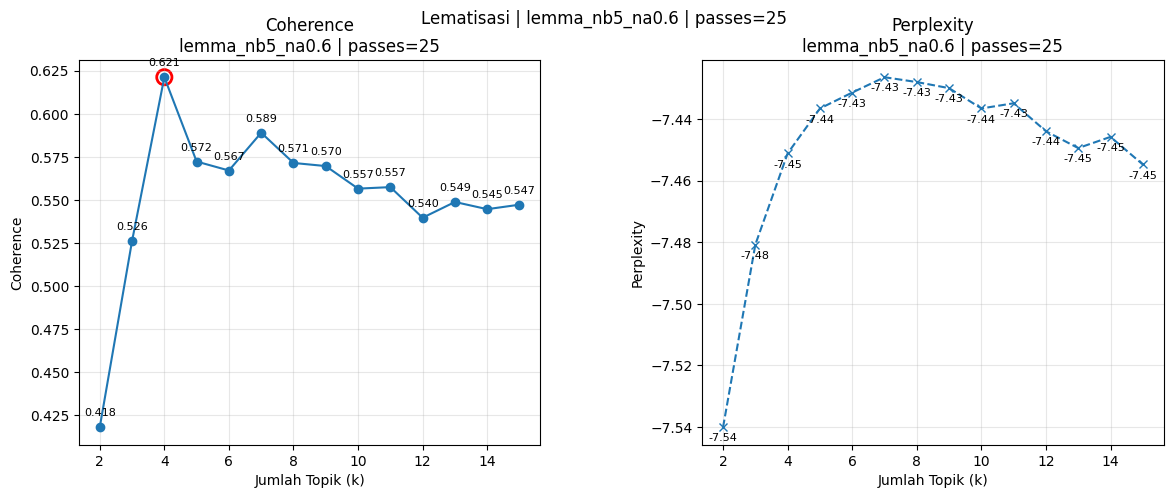

In [ ]:
plot_best_lda(df_best=df_lemma_best, df_all=df_hasil_lemma, title_prefix="Lematisasi")

### 8.1 Ekstraksi Topik — Lematisasi


In [ ]:
for _, row in df_lemma_best.iterrows():
    label = row["eksperimen"]
    k = int(row["k"])
    passes = int(row["passes"])

    print(f"\n{'=' * 60}")
    print(f"  {label} | k={k} | passes={passes}")
    print(f"{'=' * 60}")

    model_row = df_hasil_lemma[
        (df_hasil_lemma["eksperimen"] == label) &
        (df_hasil_lemma["k"] == k) &
        (df_hasil_lemma["passes"] == passes)
    ]

    if model_row.empty:
        print("Model tidak ditemukan")
        continue

    lda_model = model_row.iloc[0]["model"]
    df_topic = extract_topic_info(lda_model, num_words=25)

    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.max_rows", None)
    print(df_topic[["Topik ID", "Kata Kunci Dominan", "Rumus Probabilitas"]].to_string(index=False))
    pd.reset_option("display.max_colwidth")
    pd.reset_option("display.max_rows")


  lemma_nb5_na0.6 | k=4 | passes=25
 Topik ID                                                                                                                                                                                                                                                        Kata Kunci Dominan                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 Rumus Probabilitas
        1 Forecasting, Series, Model, Prediction, Term, Long_Short_Term_Memory, Accuracy, Neural, Long, Error, Short, Network, Feature, Transformer, Deep_Learning, Multi, T

### 8.2 Pelabelan Topik — Lematisasi


In [ ]:
# Label topik: lemma_nb5_na0.6 | k=4 | passes=25  -> MODEL FINAL TERPILIH
labels_lemma_nb5_na06_k4 = {
    1: "Forecasting dengan Deep Learning",
    2: "Penerapan AI Prediktif di Berbagai Sektor",
    3: "Seleksi Fitur untuk Klasifikasi Data",
    4: "Analisis Sentimen Opini Pengguna"
}

# Label topik: lemma_nb5_na0.05 | k=11 | passes=25
labels_lemma_nb5_na005_k11 = {
    1: "IoT Smart Energy",
    2: "Spatial Spectral Image",
    3: "COVID News Education",
    4: "Cyber Attack Detection",
    5: "Fault Diagnosis System",
    6: "Urban Food Policy",
    7: "Medical Diagnosis Healthcare",
    8: "BERT Customer Sentiment",
    9: "Financial Stock Prediction",
    10: "Software Defect Detection",
    11: "Multimodal Analysis"
}

configs_lemma = [
    {"eksperimen": "lemma_nb5_na0.6", "k": 4, "passes": 25,
     "labels": labels_lemma_nb5_na06_k4, "sheet": "lemma_nb5_na0.6_k4"},
    {"eksperimen": "lemma_nb5_na0.05", "k": 11, "passes": 25,
     "labels": labels_lemma_nb5_na005_k11, "sheet": "lemma_nb5_na0.05_k11"},
]

In [ ]:
output_excel_lemma = "lda_results/lemma_topics_labeled.xlsx"

with pd.ExcelWriter(output_excel_lemma, engine="openpyxl") as writer:
    for cfg in configs_lemma:
        print(f"\n{'=' * 60}")
        print(f"{cfg['eksperimen']} | k={cfg['k']} | passes={cfg['passes']}")
        print(f"{'=' * 60}")

        model_row = df_hasil_lemma[
            (df_hasil_lemma["eksperimen"] == cfg["eksperimen"]) &
            (df_hasil_lemma["k"] == cfg["k"]) &
            (df_hasil_lemma["passes"] == cfg["passes"])
        ]

        if model_row.empty:
            print("Model tidak ditemukan")
            continue

        lda_model = model_row.iloc[0]["model"]
        df_topic = extract_topic_info(lda_model, num_words=15)
        df_labeled = add_labels(df_topic, cfg["labels"])

        display(df_labeled[["Topik ID", "Label Topik", "Kata Kunci Dominan"]])

        df_labeled.to_excel(writer, sheet_name=cfg["sheet"], index=False)

        ws = writer.sheets[cfg["sheet"]]
        for col in ws.columns:
            max_len = max(len(str(cell.value)) if cell.value else 0 for cell in col)
            ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 60)

        print(f"✔ sheet saved: {cfg['sheet']}")

print(f"\n✅ File Excel tersimpan di:\n{output_excel_lemma}")


lemma_nb5_na0.6 | k=4 | passes=25


,Topik ID,Label Topik,Kata Kunci Dominan
0,1,Forecasting dengan Deep Learning,"Forecasting, Series, Model, Prediction, Term, ..."
1,2,Penerapan AI Prediktif di Berbagai Sektor,"Ai, Predictive, System, Energy, Management, An..."
2,3,Seleksi Fitur untuk Klasifikasi Data,"Algorithm, Feature, Accuracy, Selection, Class..."
3,4,Analisis Sentimen Opini Pengguna,"Topic, Sentiment_Analysis, Social, User, Revie..."


✔ sheet saved: lemma_nb5_na0.6_k4

lemma_nb5_na0.05 | k=11 | passes=25


,Topik ID,Label Topik,Kata Kunci Dominan
0,1,IoT Smart Energy,"Iot, Smart, Consumption, Supply, Chain, Load, ..."
1,2,Spatial Spectral Image,"Spatial, Spectral, Decomposition, Hyperspectra..."
2,3,COVID News Education,"Tweet, Covid, Education, News, Comment, Studen..."
3,4,Cyber Attack Detection,"Attack, Traffic, Intrusion, Anomaly, Device, I..."
4,5,Fault Diagnosis System,"Fault, Graph, Module, Fuzzy, Diagnosis, Sequen..."
5,6,Urban Food Policy,"Food, Urban, Safety, Policy, Construction, Pro..."
6,7,Medical Diagnosis Healthcare,"Patient, Cancer, Clinical, Student, Medical, T..."
7,8,BERT Customer Sentiment,"Customer, D_, Bert, Emotion, Arabic, Fine, Emb..."
8,9,Financial Stock Prediction,"Financial, Price, Stock, Gru, Engineering, Uni..."
9,10,Software Defect Detection,"Battery, Software, Supervised, N, Defect, Vide..."


✔ sheet saved: lemma_nb5_na0.05_k11

✅ File Excel tersimpan di:
lda_results/lemma_topics_labeled.xlsx


### 8.2b Visualisasi Distribusi Kata per Topik — Lematisasi

Sama seperti Non-Lematisasi: dua visualisasi (probabilitas & frekuensi) dengan Top-N kata yang sama, untuk kedua skenario Lematisasi — termasuk skenario `lemma_nb5_na0.6, k=4` yang merupakan **model final terpilih**.


lemma_nb5_na0.6 | k=4 | passes=25  -> MODEL FINAL TERPILIH


,Topik,Nama Topik,Kata Dominan
0,1,Forecasting dengan Deep Learning,"forecasting, series, model, prediction, term, ..."
1,2,Penerapan AI Prediktif di Berbagai Sektor,"ai, predictive, system, energy, management, an..."
2,3,Seleksi Fitur untuk Klasifikasi Data,"algorithm, feature, accuracy, selection, class..."
3,4,Analisis Sentimen Opini Pengguna,"topic, sentiment_analysis, social, user, revie..."


✔ Visualisasi disimpan: lda_results/topic_visualizations/lemma_nb5_na0.6_k4_topic_word_probability.png


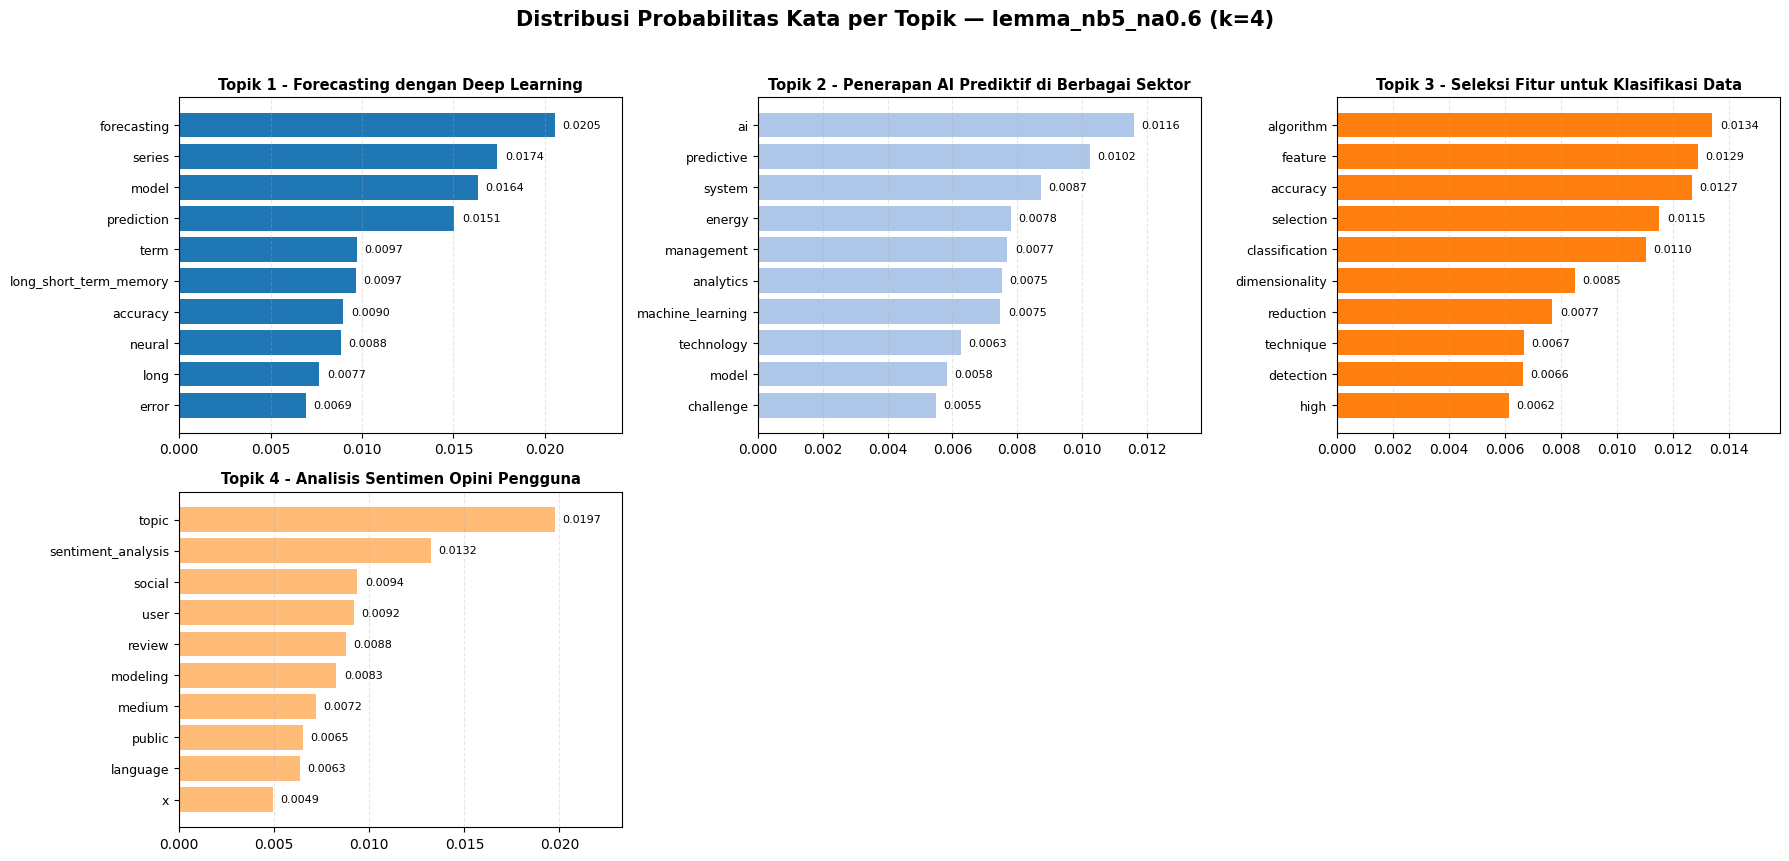

✔ Visualisasi disimpan: lda_results/topic_visualizations/lemma_nb5_na0.6_k4_topic_word_frequency.png


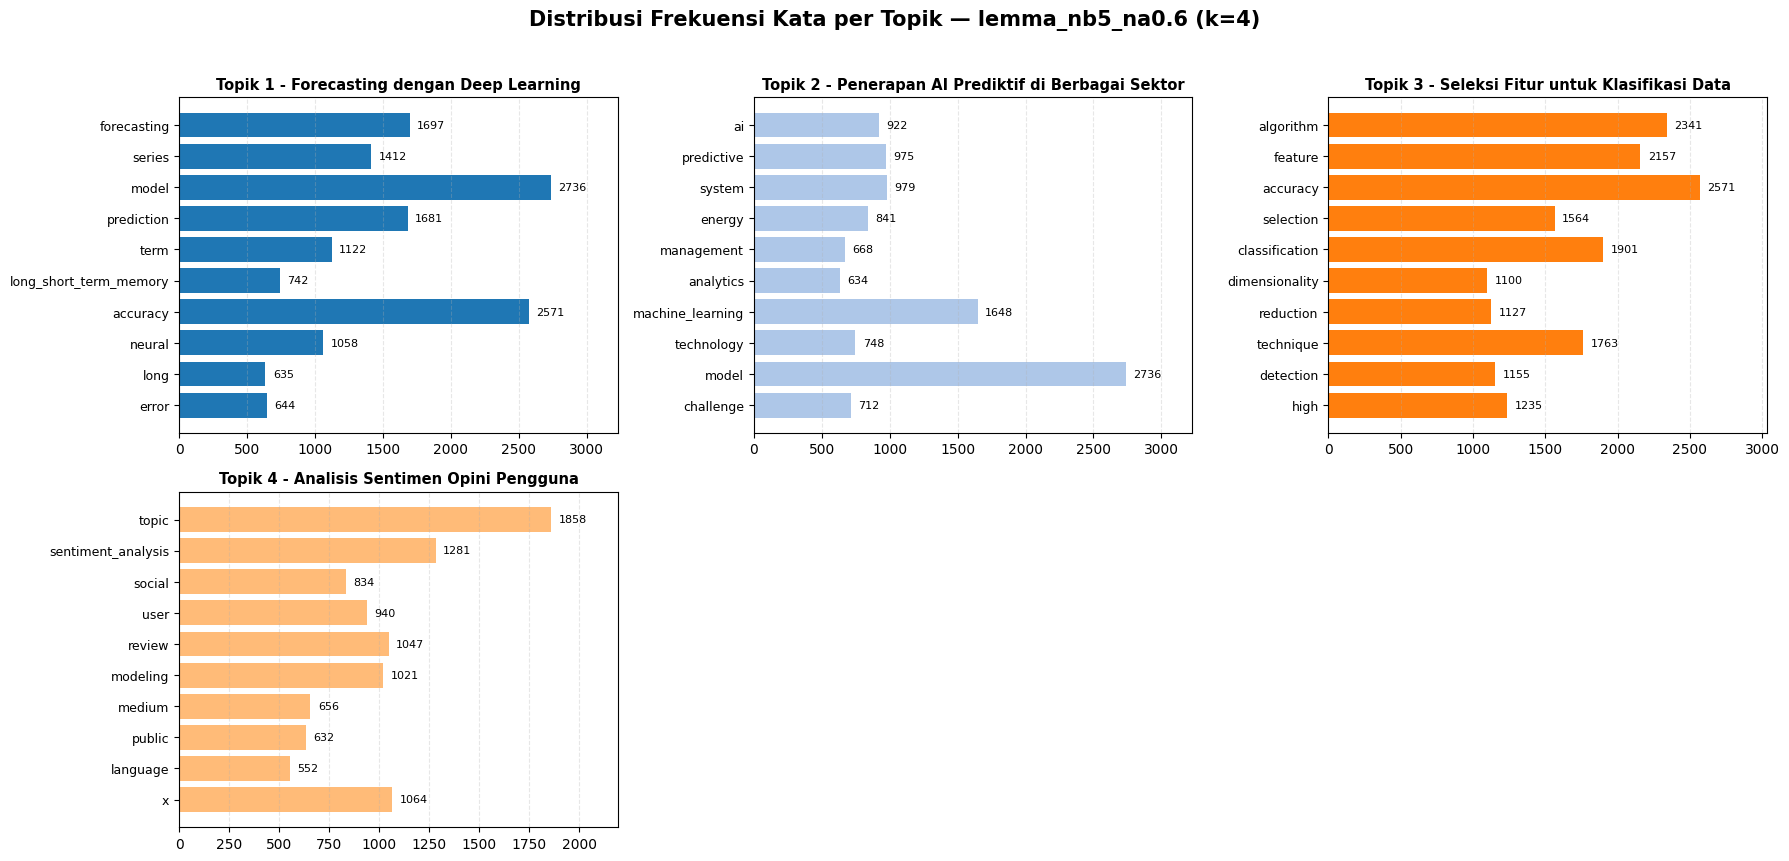


lemma_nb5_na0.05 | k=11 | passes=25


,Topik,Nama Topik,Kata Dominan
0,1,IoT Smart Energy,"iot, smart, consumption, supply, chain, load, ..."
1,2,Spatial Spectral Image,"spatial, spectral, decomposition, hyperspectra..."
2,3,COVID News Education,"tweet, covid, education, news, comment, studen..."
3,4,Cyber Attack Detection,"attack, traffic, intrusion, anomaly, device, i..."
4,5,Fault Diagnosis System,"fault, graph, module, fuzzy, diagnosis, sequen..."
5,6,Urban Food Policy,"food, urban, safety, policy, construction, pro..."
6,7,Medical Diagnosis Healthcare,"patient, cancer, clinical, student, medical, t..."
7,8,BERT Customer Sentiment,"customer, d_, bert, emotion, arabic, fine, emb..."
8,9,Financial Stock Prediction,"financial, price, stock, gru, engineering, uni..."
9,10,Software Defect Detection,"battery, software, supervised, n, defect, vide..."


✔ Visualisasi disimpan: lda_results/topic_visualizations/lemma_nb5_na0.05_k11_topic_word_probability.png


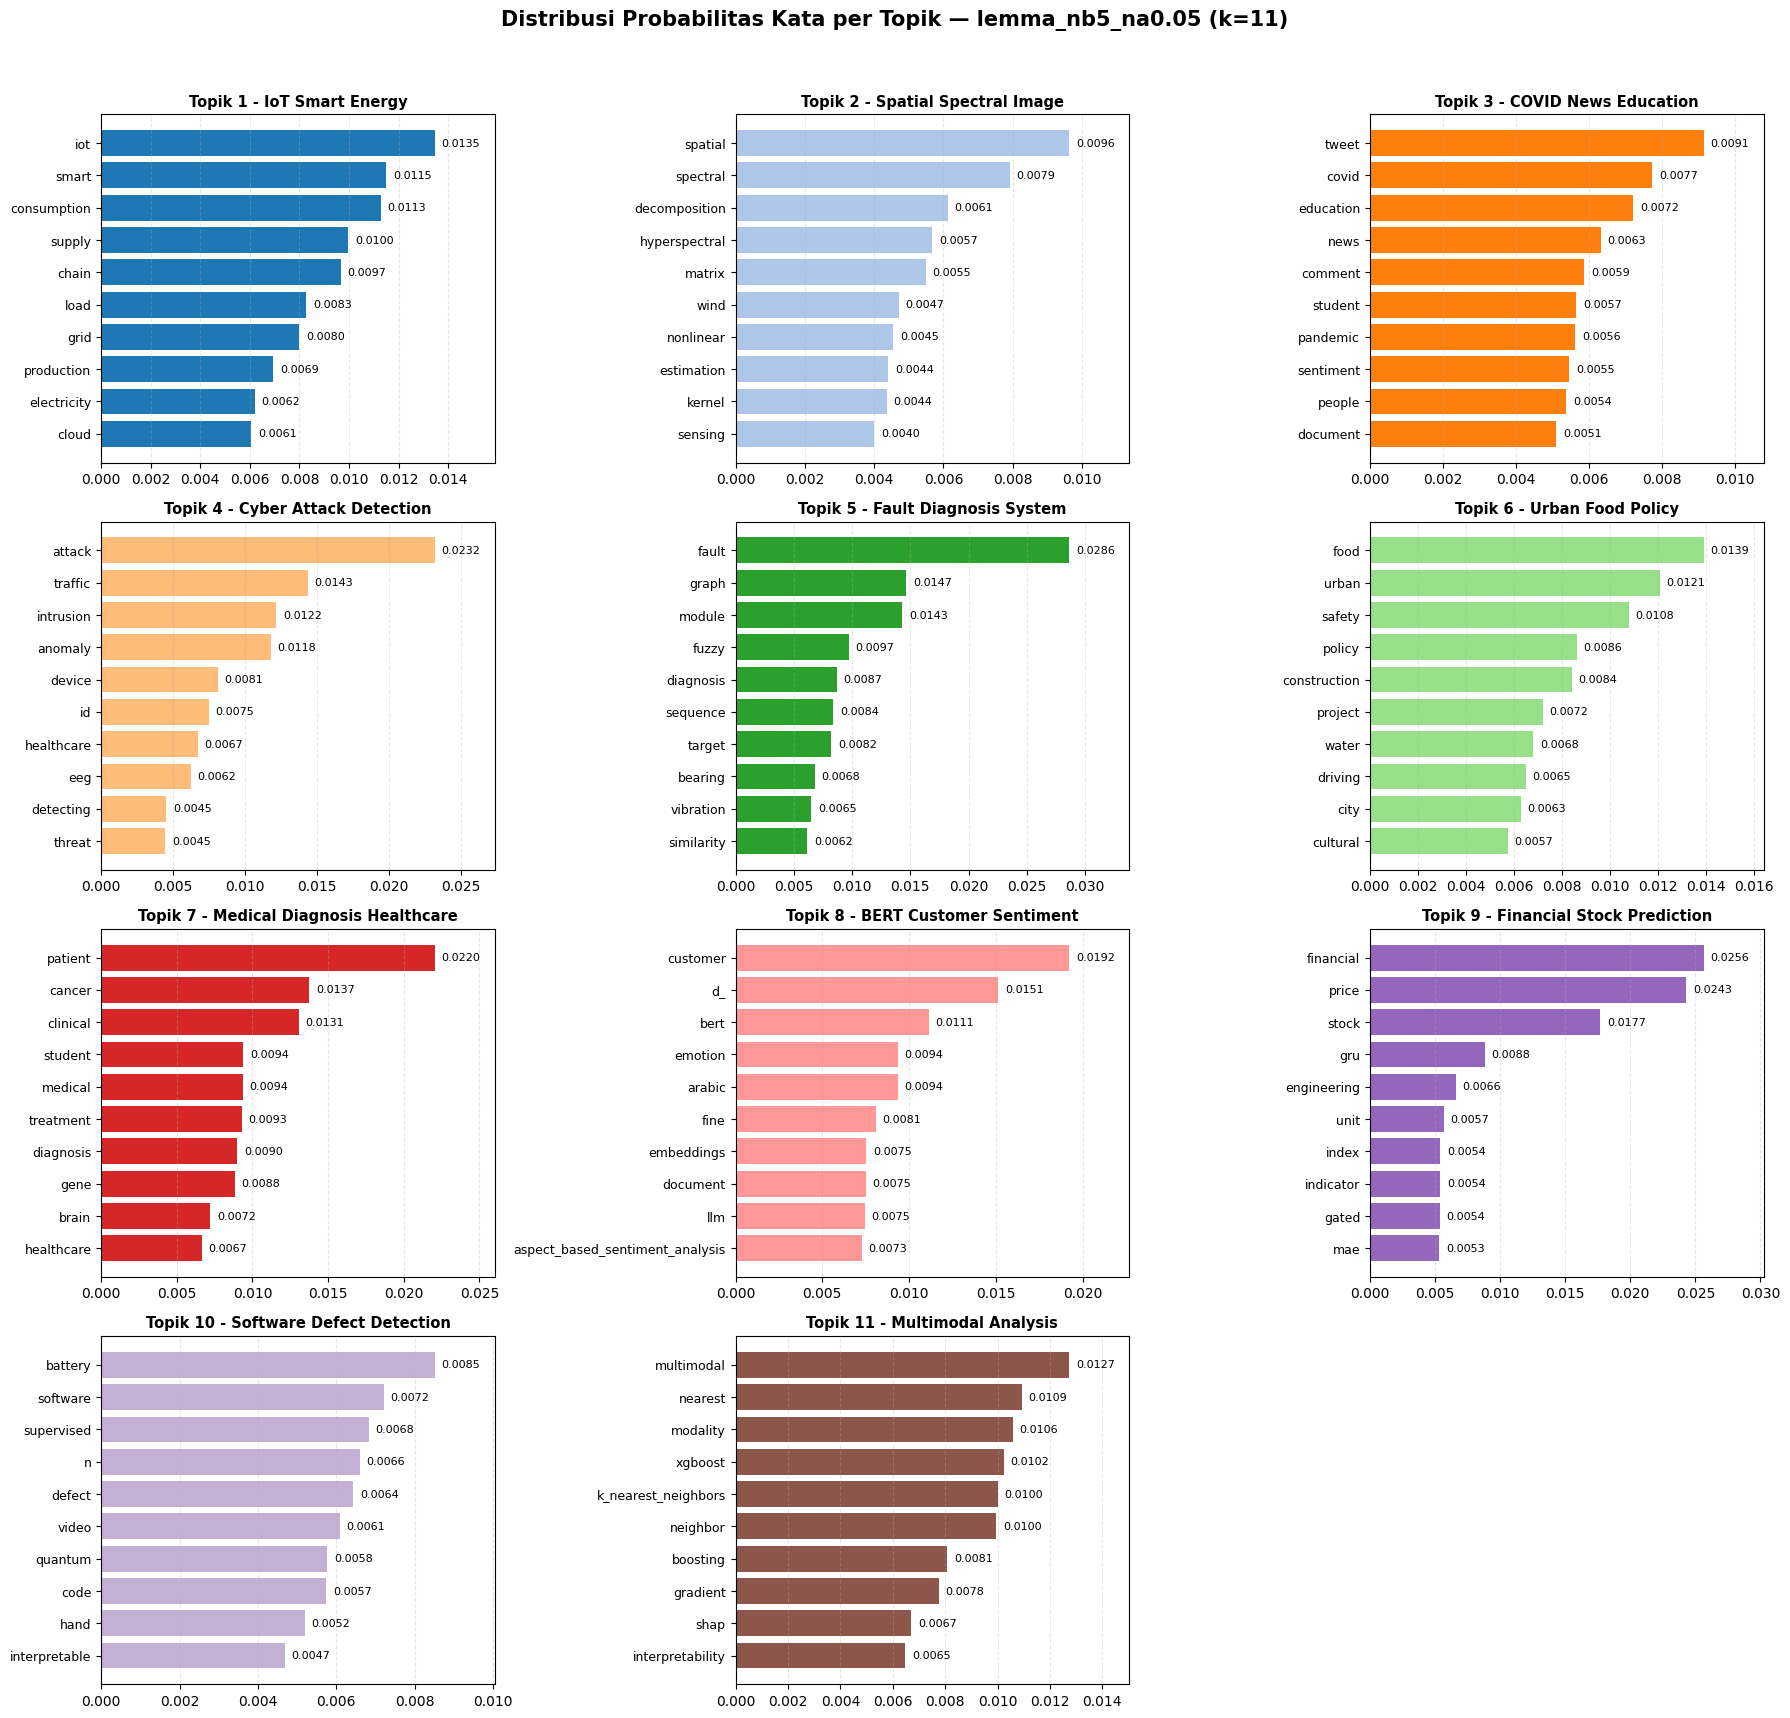

✔ Visualisasi disimpan: lda_results/topic_visualizations/lemma_nb5_na0.05_k11_topic_word_frequency.png


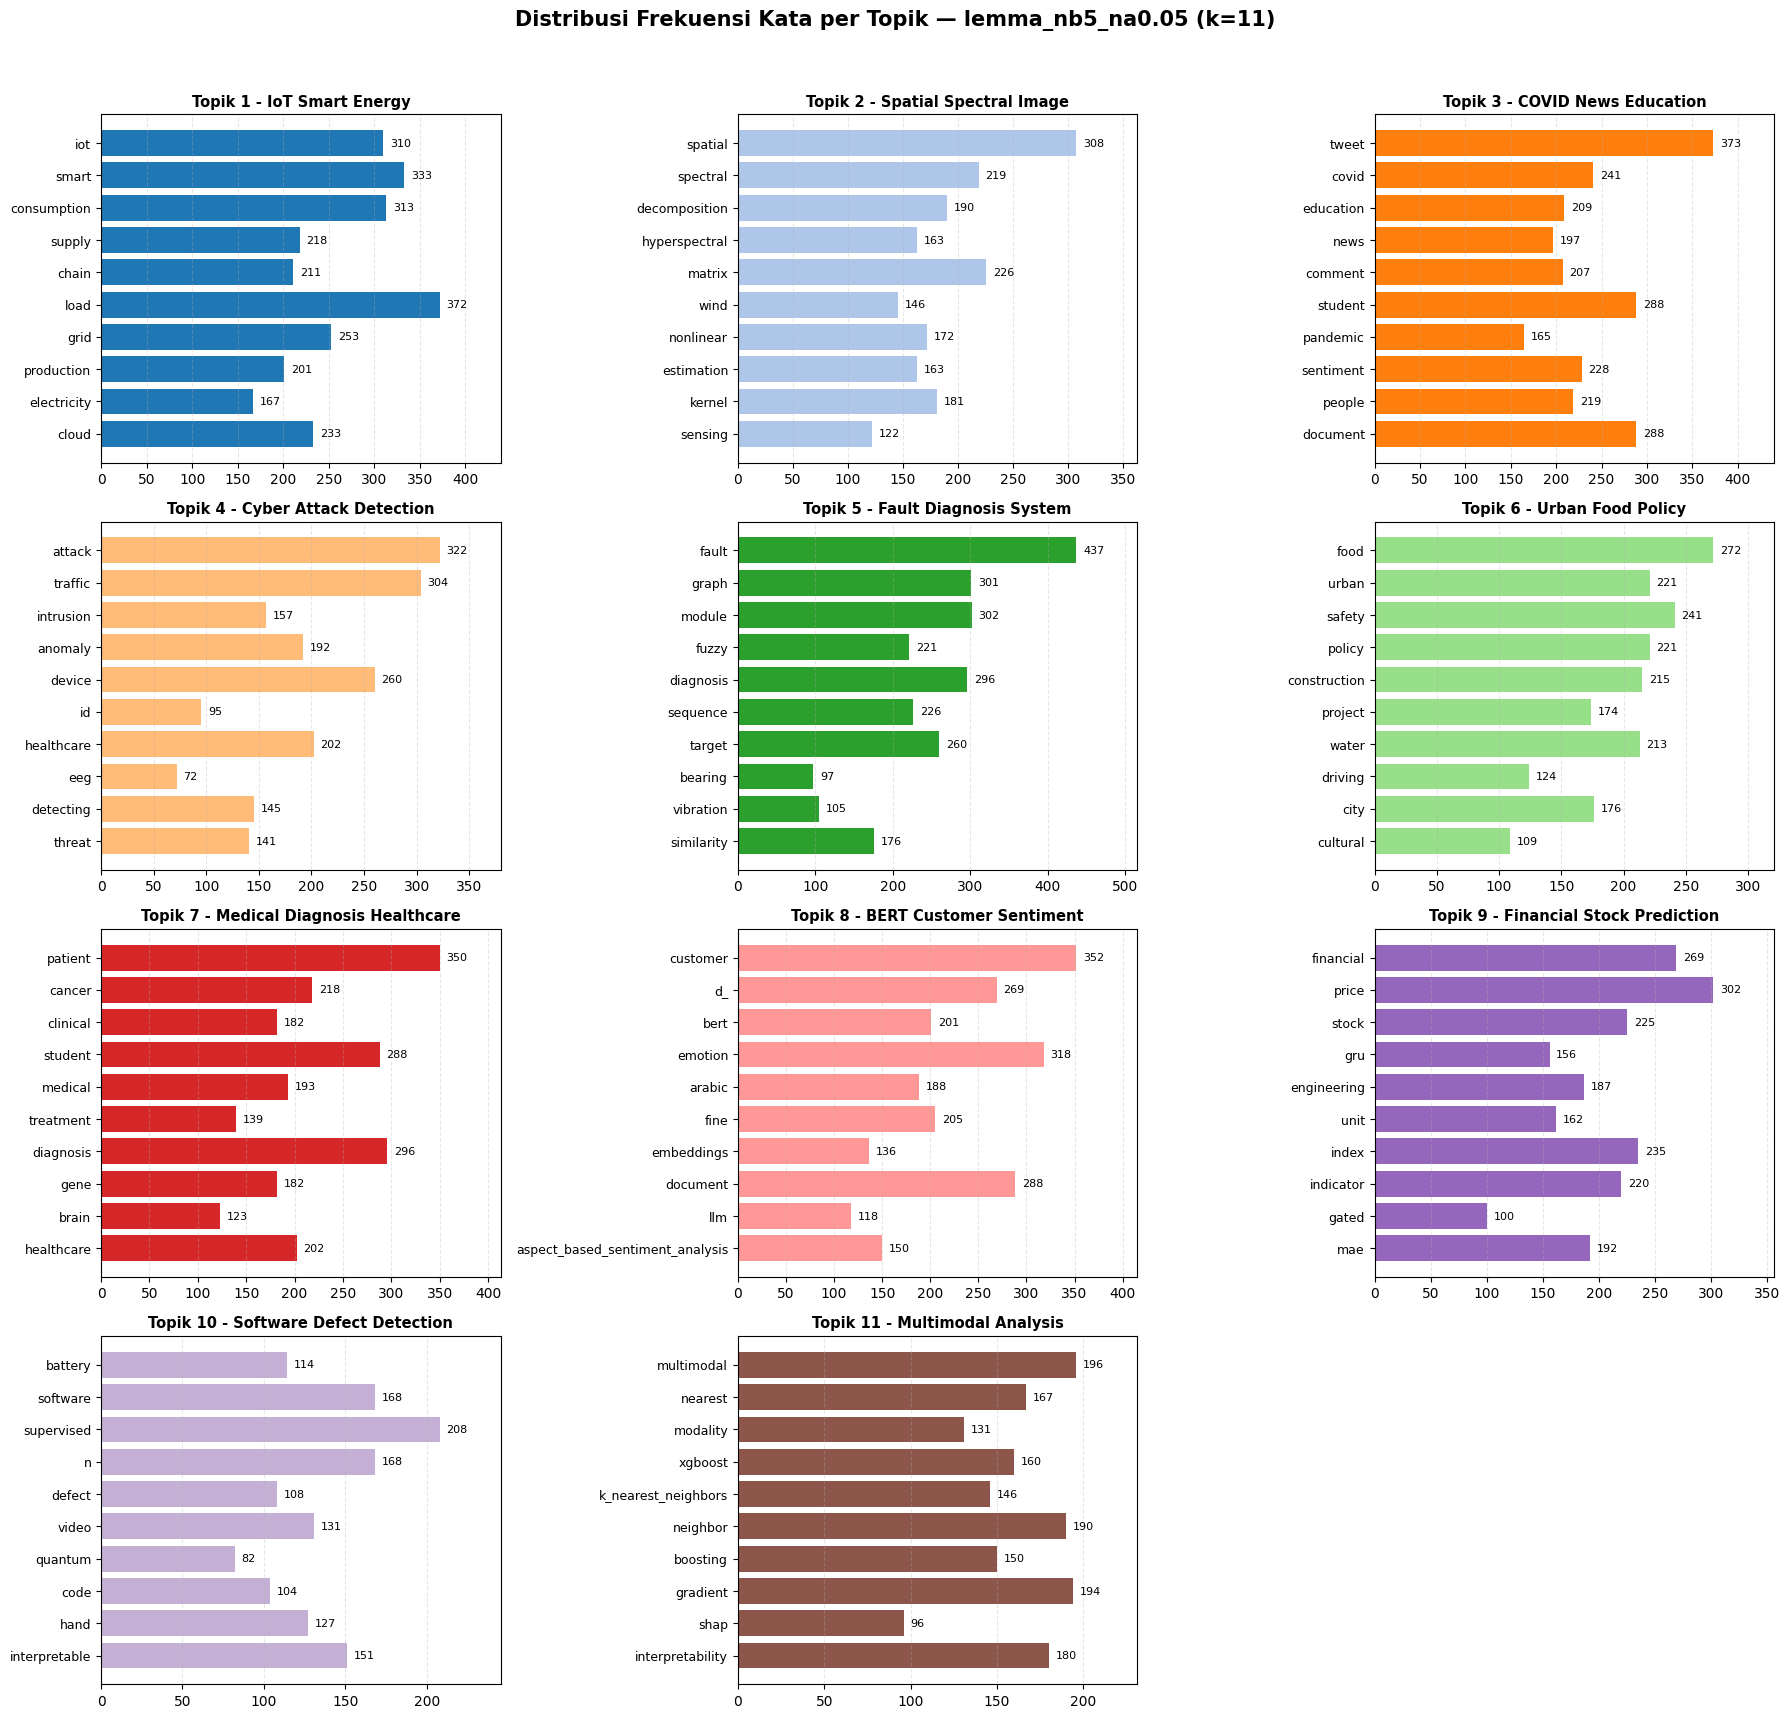

In [ ]:
for cfg in configs_lemma:
    label = cfg["eksperimen"]
    k = cfg["k"]
    passes = cfg["passes"]
    topic_labels = cfg["labels"]

    model_row = df_hasil_lemma[
        (df_hasil_lemma["eksperimen"] == label) &
        (df_hasil_lemma["k"] == k) &
        (df_hasil_lemma["passes"] == passes)
    ]
    if model_row.empty:
        print(f"Model tidak ditemukan untuk {label}")
        continue

    lda_model = model_row.iloc[0]["model"]

    top_words = get_top_words_per_topic(lda_model, num_words=TOP_N_WORDS)
    word_freq = get_topic_word_frequency(top_words, texts_lemma)

    tanda_final = "  -> MODEL FINAL TERPILIH" if (label == "lemma_nb5_na0.6" and k == 4) else ""
    print(f"\n{'=' * 60}\n{label} | k={k} | passes={passes}{tanda_final}\n{'=' * 60}")

    df_summary = create_topic_summary_table(top_words, topic_labels, num_words=TOP_N_WORDS)
    display(df_summary)

    fig_prob = plot_topic_word_distribution(
        top_words, topic_labels, value_type="probability",
        suptitle=f"Distribusi Probabilitas Kata per Topik — {label} (k={k})"
    )
    save_topic_visualization(fig_prob, f"{label}_k{k}_topic_word_probability.png")
    plt.show()

    fig_freq = plot_topic_word_distribution(
        word_freq, topic_labels, value_type="frequency",
        suptitle=f"Distribusi Frekuensi Kata per Topik — {label} (k={k})"
    )
    save_topic_visualization(fig_freq, f"{label}_k{k}_topic_word_frequency.png")
    plt.show()


### 8.3 Penggabungan Hasil Topik ke Dataset — Lematisasi


In [ ]:
df_lemma_src = df_lda.copy()
os.makedirs("lda_dataset/lemma", exist_ok=True)

for cfg in configs_lemma:
    print(f"\nMemproses {cfg['eksperimen']}")

    model_row = df_hasil_lemma[
        (df_hasil_lemma["eksperimen"] == cfg["eksperimen"]) &
        (df_hasil_lemma["k"] == cfg["k"]) &
        (df_hasil_lemma["passes"] == cfg["passes"])
    ]

    if model_row.empty:
        print("Model tidak ditemukan")
        continue

    lda_model = model_row.iloc[0]["model"]
    corpus = gensim_lemma[cfg["eksperimen"]]["corpus"]
    k = cfg["k"]

    topic_vectors, dominant_topics = get_topic_distribution_full(lda_model, corpus, k)

    df_final = df_lemma_src.copy()
    df_final = df_final.rename(columns={"lemmatization": "lemma_text"})
    df_final = df_final[["Year", "clean_text", "lemma_text"]]

    for i in range(k):
        df_final[f"topic_{i + 1}"] = topic_vectors[:, i]

    df_final["topik_dominan"] = [x[0] for x in dominant_topics]
    df_final["probabilitas_topik"] = [x[1] for x in dominant_topics]
    df_final["label_topik"] = df_final["topik_dominan"].map(cfg["labels"])

    output_path = f"lda_dataset/lemma/{cfg['eksperimen']}_k{cfg['k']}_p{cfg['passes']}.csv"
    df_final.to_csv(output_path, index=False)

    print(f"✔ saved: {output_path}")
    display(df_final.head())


Memproses lemma_nb5_na0.6
✔ saved: lda_dataset/lemma/lemma_nb5_na0.6_k4_p25.csv


,Year,clean_text,lemma_text,topic_1,topic_2,topic_3,topic_4,topik_dominan,probabilitas_topik,label_topik
0,2020,today digital world demands about automated se...,"[demand, automated, sentiment_analysis, visual...",0.215524,0.002478,0.081028,0.700970,4,0.700970,Analisis Sentimen Opini Pengguna
1,2020,sentiment_analysis is focused on mining opinio...,"[sentiment_analysis, mining, opinion, classifi...",0.107211,0.001242,0.269508,0.622039,4,0.622039,Analisis Sentimen Opini Pengguna
2,2020,aspect_based_sentiment_analysis has recently a...,"[aspect_based_sentiment_analysis, attracted, e...",0.159760,0.001132,0.001398,0.837710,4,0.837710,Analisis Sentimen Opini Pengguna
3,2020,in the era of web online forums blogs and twit...,"[twitter, primary, source, view, opinion, comm...",0.001481,0.001859,0.520668,0.475991,3,0.520668,Seleksi Fitur untuk Klasifikasi Data
4,2020,financial and economic news is continuously mo...,"[financial, economic, news, continuously, moni...",0.304790,0.088474,0.001459,0.605277,4,0.605277,Analisis Sentimen Opini Pengguna



Memproses lemma_nb5_na0.05
✔ saved: lda_dataset/lemma/lemma_nb5_na0.05_k11_p25.csv


,Year,clean_text,lemma_text,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topik_dominan,probabilitas_topik,label_topik
0,2020,today digital world demands about automated se...,"[demand, automated, sentiment_analysis, visual...",0.004490,0.004473,0.432132,0.002830,0.003219,0.003546,0.002588,0.286442,0.002570,0.003166,0.254544,3,0.432132,COVID News Education
1,2020,sentiment_analysis is focused on mining opinio...,"[sentiment_analysis, mining, opinion, classifi...",0.002552,0.002546,0.322106,0.001611,0.283288,0.002019,0.001474,0.189361,0.001463,0.191883,0.001697,3,0.322106,COVID News Education
2,2020,aspect_based_sentiment_analysis has recently a...,"[aspect_based_sentiment_analysis, attracted, e...",0.002710,0.002703,0.002606,0.001712,0.151306,0.002145,0.001565,0.720297,0.001554,0.111599,0.001803,8,0.720297,BERT Customer Sentiment
3,2020,in the era of web online forums blogs and twit...,"[twitter, primary, source, view, opinion, comm...",0.004483,0.403340,0.389154,0.002830,0.003220,0.003547,0.002588,0.182121,0.002570,0.003167,0.002981,2,0.403340,Spatial Spectral Image
4,2020,financial and economic news is continuously mo...,"[financial, economic, news, continuously, moni...",0.002106,0.002091,0.244449,0.001326,0.001509,0.001662,0.001213,0.395683,0.347081,0.001484,0.001397,8,0.395683,BERT Customer Sentiment


### 8.4 Visualisasi Interaktif Topik — Lematisasi (pyLDAvis)


In [ ]:
os.makedirs("lda_vis/lemma", exist_ok=True)

for _, row in df_lemma_best.iterrows():
    label = row["eksperimen"]
    k = int(row["k"])
    passes = int(row["passes"])

    model_row = df_hasil_lemma[
        (df_hasil_lemma["eksperimen"] == label) &
        (df_hasil_lemma["k"] == k) &
        (df_hasil_lemma["passes"] == passes)
    ]

    if model_row.empty:
        continue

    lda_model = model_row.iloc[0]["model"]
    corpus = gensim_lemma[label]["corpus"]
    dictionary = gensim_lemma[label]["dict"]

    vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)

    display(HTML(f"<h3>{label} | k={k} | passes={passes}</h3>"))
    display(pyLDAvis.display(vis))

## 9. Analisis Hasil & Perbandingan Skenario

### 9.1 Rekap Seluruh Eksperimen Terbaik

Menggabungkan model terbaik dari skenario Non-Lematisasi dan Lematisasi untuk dibandingkan dalam satu tabel.


In [ ]:
best_nonlemma_all = df_nonlemma_best.sort_values(by="coherence", ascending=False).reset_index(drop=True)
best_lemma_all = df_lemma_best.sort_values(by="coherence", ascending=False).reset_index(drop=True)

df_rekap_eksperimen = pd.concat([best_nonlemma_all, best_lemma_all]).reset_index(drop=True)

df_rekap_eksperimen["skenario"] = [
    "non_lematisasi" if "lemma" not in exp.replace("non_lemma", "") else "lematisasi"
    for exp in df_rekap_eksperimen["eksperimen"]
]

df_rekap_eksperimen = df_rekap_eksperimen[
    ["skenario", "eksperimen", "passes", "k", "coherence", "perplexity"]
].sort_values(by="coherence", ascending=False).reset_index(drop=True)

display(df_rekap_eksperimen)

,skenario,eksperimen,passes,k,coherence,perplexity
0,lematisasi,lemma_nb5_na0.6,25,4,0.621200,-7.451118
1,non_lematisasi,non_lemma_nb5_na0.6,25,5,0.605171,-7.603399
2,non_lematisasi,non_lemma_nb5_na0.05,25,13,0.478314,-8.097389
3,lematisasi,lemma_nb5_na0.05,25,11,0.439922,-7.923677


### 9.2 Analisis Model Terbaik per Skenario

Mengambil **satu model terbaik** (berdasarkan Coherence Score tertinggi) dari masing-masing skenario, sebagai kandidat model final.


In [ ]:
best_nonlemma_1 = df_nonlemma_best.sort_values("coherence", ascending=False).iloc[0]
best_lemma_1 = df_lemma_best.sort_values("coherence", ascending=False).iloc[0]

df_kandidat_final = pd.DataFrame([best_lemma_1, best_nonlemma_1]).reset_index(drop=True)
df_kandidat_final["skenario"] = ["lematisasi", "non_lematisasi"]

df_kandidat_final = df_kandidat_final.sort_values(by="coherence", ascending=False).reset_index(drop=True)

display(df_kandidat_final[["skenario", "eksperimen", "passes", "k", "coherence", "perplexity"]])

,skenario,eksperimen,passes,k,coherence,perplexity
0,lematisasi,lemma_nb5_na0.6,25,4,0.621200,-7.451118
1,non_lematisasi,non_lemma_nb5_na0.6,25,5,0.605171,-7.603399


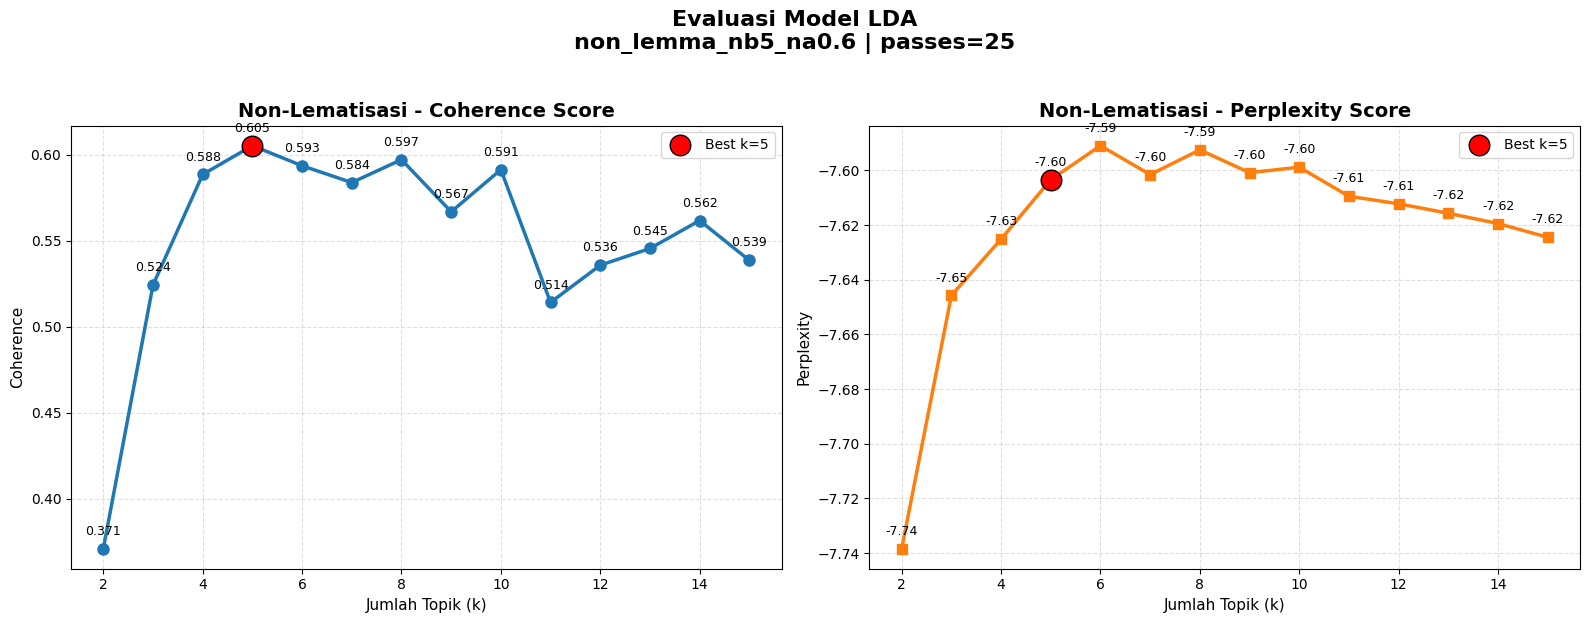

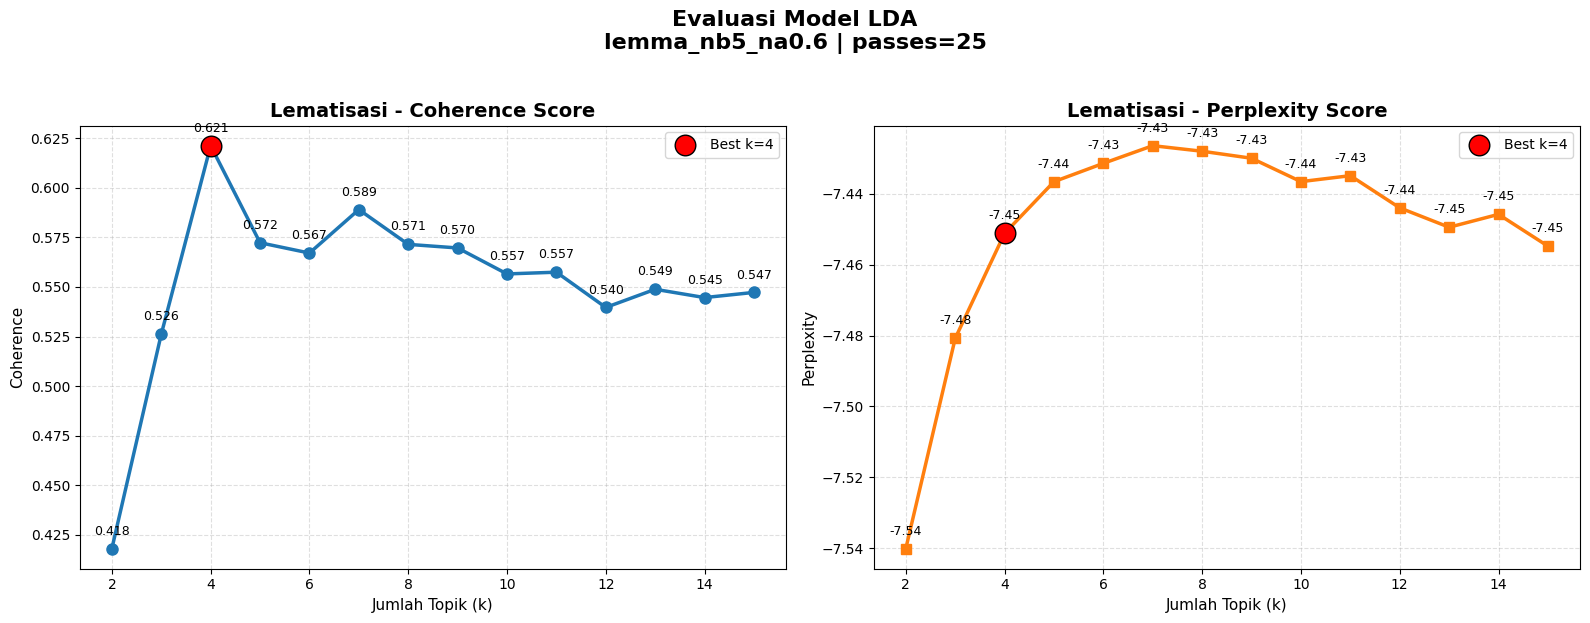

In [ ]:
def plot_skenario_line(df_hasil, best_row, title):
    """Plot Coherence & Perplexity untuk satu eksperimen terbaik, dengan titik k terbaik ditandai."""
    label = best_row["eksperimen"]
    passes = best_row["passes"]

    df_plot = df_hasil[
        (df_hasil["eksperimen"] == label) & (df_hasil["passes"] == passes)
    ].sort_values("k")

    best_k = best_row["k"]
    best_coh = best_row["coherence"]
    best_perp = best_row["perplexity"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(df_plot["k"], df_plot["coherence"], marker='o', linewidth=2.5, markersize=8, color='#1f77b4')
    axes[0].scatter(best_k, best_coh, s=220, color='red', edgecolor='black', zorder=5, label=f'Best k={best_k}')
    for _, row in df_plot.iterrows():
        axes[0].annotate(f"{row['coherence']:.3f}", (row["k"], row["coherence"]),
                          textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
    axes[0].set_title(f"{title} - Coherence Score", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Jumlah Topik (k)", fontsize=11)
    axes[0].set_ylabel("Coherence", fontsize=11)
    axes[0].grid(linestyle='--', alpha=0.4)
    axes[0].legend()

    axes[1].plot(df_plot["k"], df_plot["perplexity"], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
    axes[1].scatter(best_k, best_perp, s=220, color='red', edgecolor='black', zorder=5, label=f'Best k={best_k}')
    for _, row in df_plot.iterrows():
        axes[1].annotate(f"{row['perplexity']:.2f}", (row["k"], row["perplexity"]),
                          textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
    axes[1].set_title(f"{title} - Perplexity Score", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Jumlah Topik (k)", fontsize=11)
    axes[1].set_ylabel("Perplexity", fontsize=11)
    axes[1].grid(linestyle='--', alpha=0.4)
    axes[1].legend()

    plt.suptitle(f"Evaluasi Model LDA\n{label} | passes={passes}", fontsize=16, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()


plot_skenario_line(df_hasil_nonlemma, best_nonlemma_1, title="Non-Lematisasi")
plot_skenario_line(df_hasil_lemma, best_lemma_1, title="Lematisasi")

### 9.3 Penentuan Model Final

Model final dipilih berdasarkan **Coherence Score tertinggi** di antara kandidat terbaik kedua skenario.


In [ ]:
final_model_row = df_kandidat_final.sort_values(by="coherence", ascending=False).iloc[0]

print("MODEL FINAL TERPILIH:")
display(final_model_row[["skenario", "eksperimen", "passes", "k", "coherence", "perplexity"]])

MODEL FINAL TERPILIH:


,0
skenario,lematisasi
eksperimen,lemma_nb5_na0.6
passes,25
k,4
coherence,0.6212
perplexity,-7.451118


## 10. Interpretasi dan Pelabelan Topik — Model Final

Model final terpilih (**Lematisasi, `no_below=5`, `no_above=0.6`, k=4**) dianalisis lebih lanjut: distribusi dokumen antar topik, distribusi topik per tahun, dan interpretasi naratif tiap topik.


In [ ]:
model_final = pd.read_excel('/content/lematisasi_nb5_na0.6_k4_dataset_new.xlsx')
model_final

,Year,clean_text,lemma_text,topic_1,topic_2,topic_3,topic_4,topik_dominan,probabilitas_topik,label_topik
0,2020,today digital world demands about automated se...,"['demand', 'automated', 'sentiment_analysis', ...",0.215532,0.002478,0.081011,0.700979,4,0.700979,Analisis Sentimen Opini Pengguna
1,2020,sentiment_analysis is focused on mining opinio...,"['sentiment_analysis', 'mining', 'opinion', 'c...",0.107206,0.001242,0.269512,0.622039,4,0.622039,Analisis Sentimen Opini Pengguna
2,2020,aspect_based_sentiment_analysis has recently a...,"['aspect_based_sentiment_analysis', 'attracted...",0.159668,0.001132,0.001398,0.837802,4,0.837802,Analisis Sentimen Opini Pengguna
3,2020,in the era of web online forums blogs and twit...,"['twitter', 'primary', 'source', 'view', 'opin...",0.001481,0.001859,0.520663,0.475996,3,0.520663,Seleksi Fitur untuk Klasifikasi Data
4,2020,financial and economic news is continuously mo...,"['financial', 'economic', 'news', 'continuousl...",0.304786,0.088478,0.001459,0.605277,4,0.605277,Analisis Sentimen Opini Pengguna
...,...,...,...,...,...,...,...,...,...,...
3321,2026,this debate examines how climate change presen...,"['debate', 'examines', 'climate', 'present', '...",0.000614,0.926147,0.000949,0.072291,2,0.926147,Penerapan AI Prediktif di Berbagai Sektor
3322,2026,the current literature on electrical maintenan...,"['current', 'literature', 'electrical', 'maint...",0.000621,0.935992,0.000958,0.062429,2,0.935992,Penerapan AI Prediktif di Berbagai Sektor
3323,2026,this proposes a hybrid automated machine_learn...,"['hybrid', 'automated', 'machine_learning', 'a...",0.000712,0.450269,0.548307,0.000712,3,0.548307,Seleksi Fitur untuk Klasifikasi Data
3324,2026,the rapid expansion of artificial intelligence...,"['rapid', 'expansion', 'artificial', 'intellig...",0.000644,0.669194,0.000994,0.329168,2,0.669194,Penerapan AI Prediktif di Berbagai Sektor


### 10.1 Deskripsi Naratif Topik

Interpretasi makna tiap topik berdasarkan kata kunci dominannya, untuk membantu pembacaan hasil di luar sekadar label singkat.


In [ ]:
df_interpretasi_topik = pd.DataFrame({
    "Topik ID": [1, 2, 3, 4],
    "Label Topik": [
        "Forecasting dengan Deep Learning",
        "Penerapan AI Prediktif di Berbagai Sektor",
        "Seleksi Fitur untuk Klasifikasi Data",
        "Analisis Sentimen Opini Pengguna"
    ],
    "Deskripsi": [
        "Topik membahas forecasting dan prediksi data menggunakan model deep learning seperti LSTM, neural network, dan transformer.",
        "Topik membahas predictive analytics untuk membantu proses pengambilan keputusan berbasis data menggunakan artificial intelligence dan machine learning.",
        "Topik membahas klasifikasi machine learning, feature selection, dimensionality reduction, dan optimasi model.",
        "Topik membahas natural language processing yang mencakup analisis sentimen, opini pengguna, dan pengolahan data teks."
    ]
})

display(df_interpretasi_topik)

,Topik ID,Label Topik,Deskripsi
0,1,Forecasting dengan Deep Learning,Topik membahas forecasting dan prediksi data m...
1,2,Penerapan AI Prediktif di Berbagai Sektor,Topik membahas predictive analytics untuk memb...
2,3,Seleksi Fitur untuk Klasifikasi Data,"Topik membahas klasifikasi machine learning, f..."
3,4,Analisis Sentimen Opini Pengguna,Topik membahas natural language processing yan...


### 10.1b Ringkasan & Visualisasi Distribusi Kata — Model Final

Tabel ringkasan dan visualisasi Top-10 kata (probabilitas & frekuensi) khusus untuk model final (**Lematisasi, no_below=5, no_above=0.6, k=4**), diambil ulang dari model yang sama di Section 8 supaya siap pakai langsung untuk pembahasan Bab 4.

RINGKASAN TOPIK — MODEL FINAL


,Topik,Nama Topik,Kata Dominan
0,1,Forecasting dengan Deep Learning,"forecasting, series, model, prediction, term, ..."
1,2,Penerapan AI Prediktif di Berbagai Sektor,"ai, predictive, system, energy, management, an..."
2,3,Seleksi Fitur untuk Klasifikasi Data,"algorithm, feature, accuracy, selection, class..."
3,4,Analisis Sentimen Opini Pengguna,"topic, sentiment_analysis, social, user, revie..."


✔ Visualisasi disimpan: lda_results/topic_visualizations/final_model_topic_word_probability.png


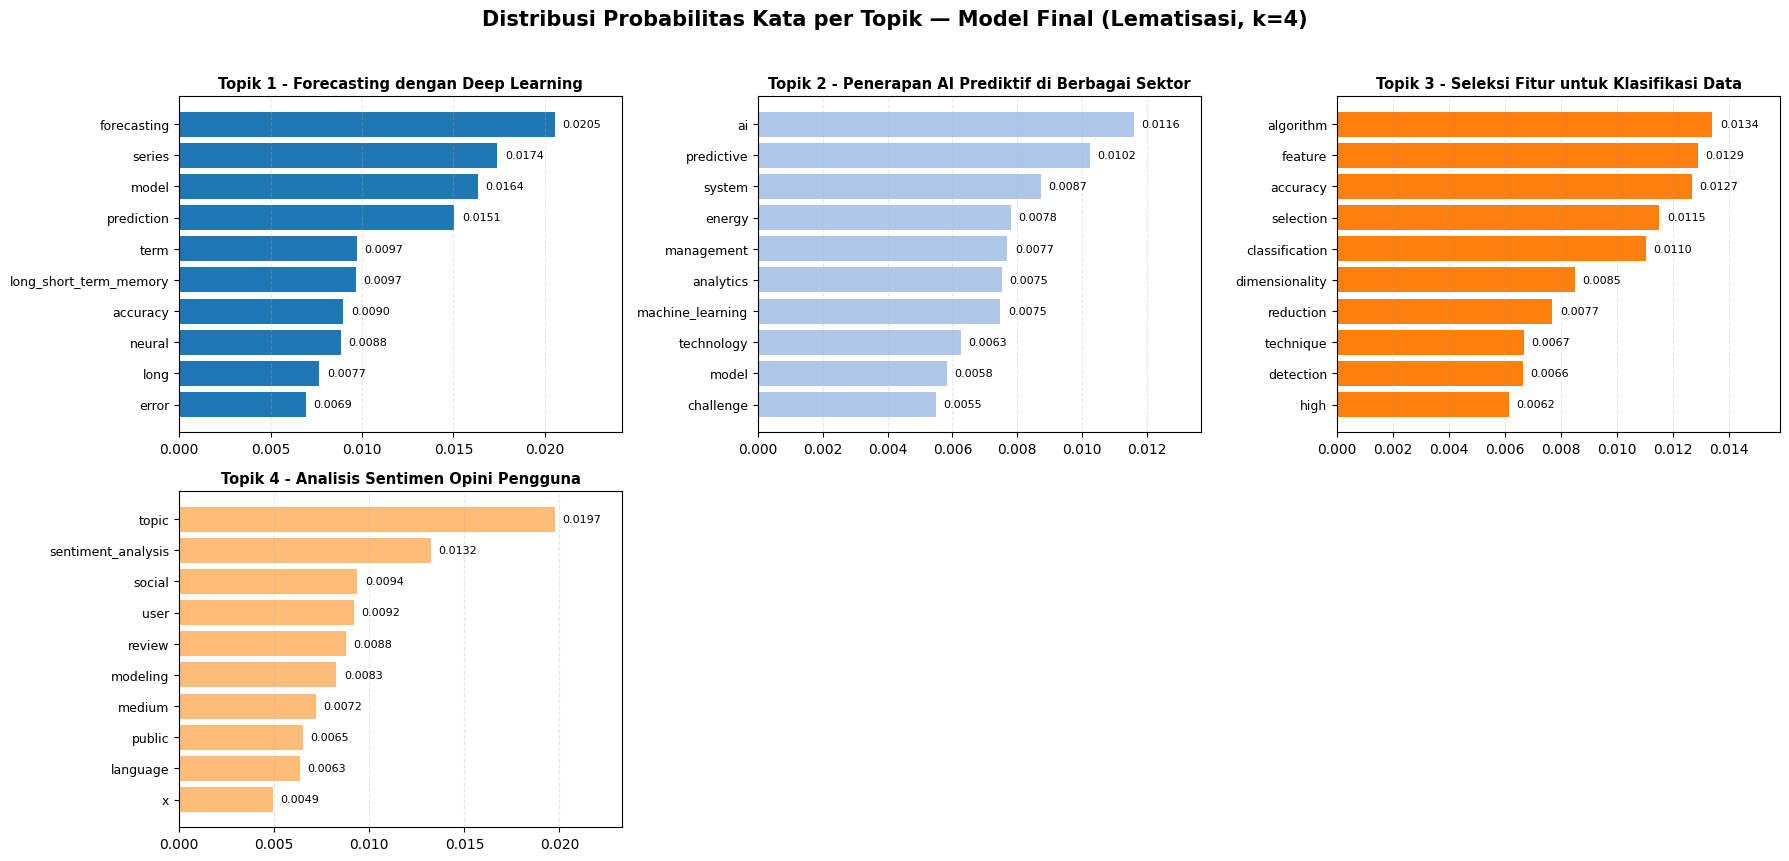

✔ Visualisasi disimpan: lda_results/topic_visualizations/final_model_topic_word_frequency.png


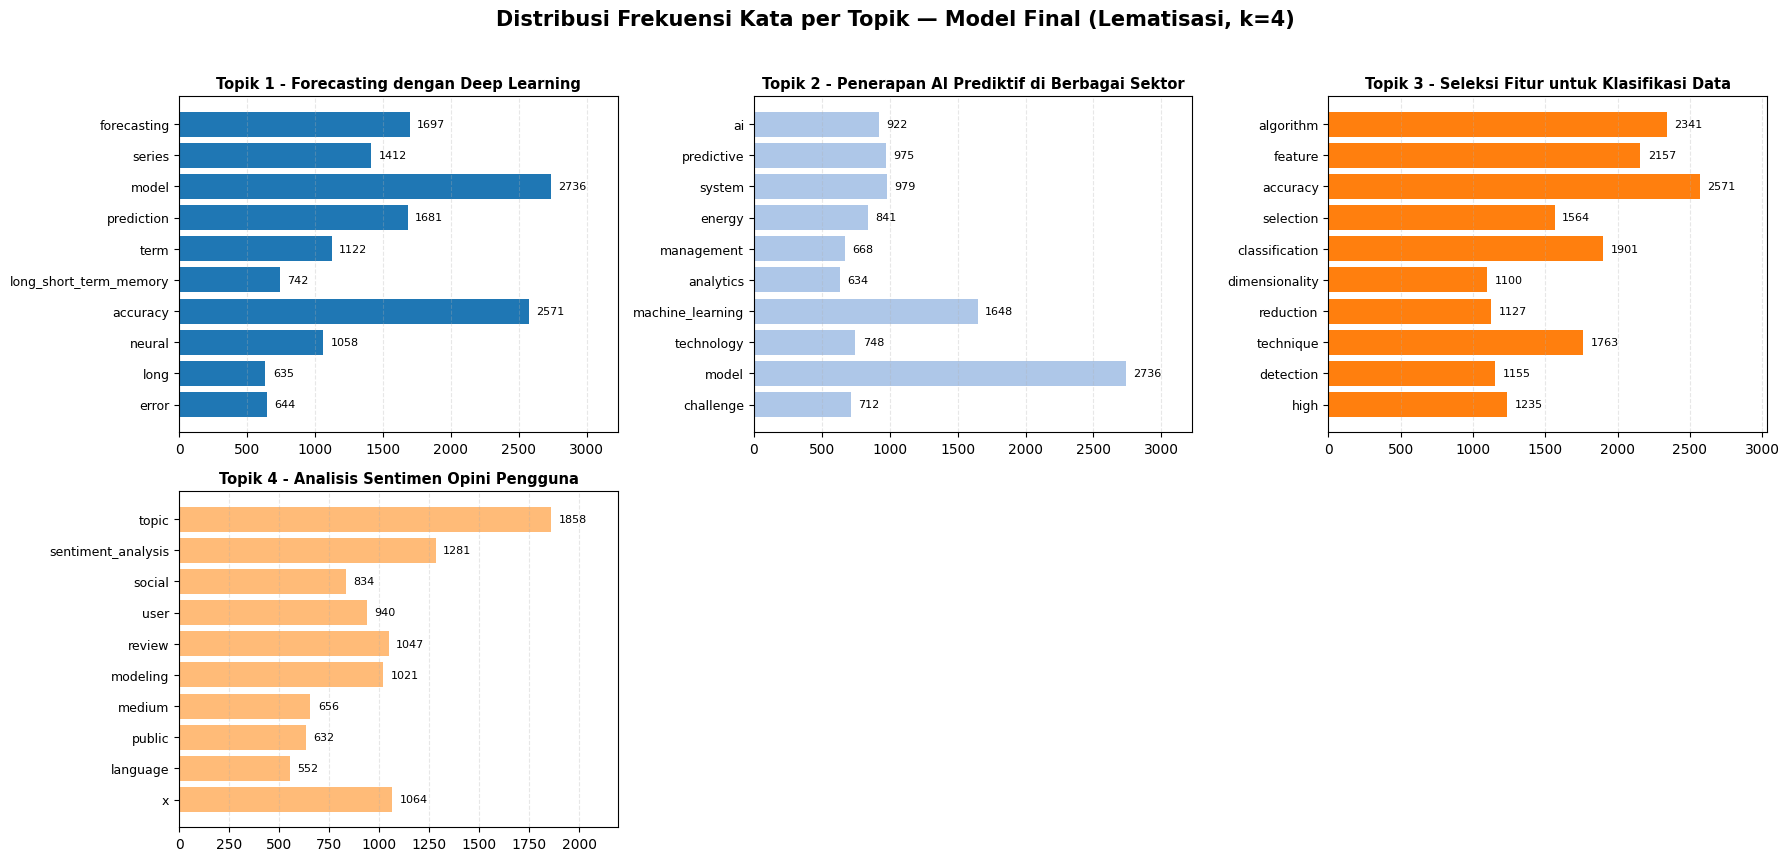

In [ ]:
FINAL_EKSPERIMEN = "lemma_nb5_na0.6"
FINAL_K = 4
FINAL_PASSES = 25
final_topic_labels = labels_lemma_nb5_na06_k4

final_model_row_viz = df_hasil_lemma[
    (df_hasil_lemma["eksperimen"] == FINAL_EKSPERIMEN) &
    (df_hasil_lemma["k"] == FINAL_K) &
    (df_hasil_lemma["passes"] == FINAL_PASSES)
]

if final_model_row_viz.empty:
    print("Model final tidak ditemukan di df_hasil_lemma.")
else:
    lda_model_final = final_model_row_viz.iloc[0]["model"]

    top_words_final = get_top_words_per_topic(lda_model_final, num_words=TOP_N_WORDS)
    word_freq_final = get_topic_word_frequency(top_words_final, texts_lemma)

    print("RINGKASAN TOPIK — MODEL FINAL")
    df_summary_final = create_topic_summary_table(top_words_final, final_topic_labels, num_words=TOP_N_WORDS)
    display(df_summary_final)

    fig_prob_final = plot_topic_word_distribution(
        top_words_final, final_topic_labels, value_type="probability",
        suptitle="Distribusi Probabilitas Kata per Topik — Model Final (Lematisasi, k=4)"
    )
    save_topic_visualization(fig_prob_final, "final_model_topic_word_probability.png")
    plt.show()

    fig_freq_final = plot_topic_word_distribution(
        word_freq_final, final_topic_labels, value_type="frequency",
        suptitle="Distribusi Frekuensi Kata per Topik — Model Final (Lematisasi, k=4)"
    )
    save_topic_visualization(fig_freq_final, "final_model_topic_word_frequency.png")
    plt.show()


### 10.2 Distribusi Dokumen per Topik


In [ ]:
# plt.figure(figsize=(10, 6))

# topic_order = model_final['label_topik'].value_counts().index

# contrast_colors = [
#     '#e41a1c', '#377eb8', '#4daf4a', '#984ea3',
#     '#ff7f00', '#ffff33', '#a65628', '#f781bf',
#     '#1f78b4', '#33a02c', '#fb9a99', '#6a3d9a'
# ]

# ax = sns.countplot(
#     data=model_final,
#     x='label_topik',
#     order=topic_order,
#     palette=contrast_colors[:len(topic_order)]
# )

# for p in ax.patches:
#     ax.annotate(
#         f'{int(p.get_height())}',
#         (p.get_x() + p.get_width() / 2., p.get_height()),
#         ha='center', va='center',
#         xytext=(0, 9), textcoords='offset points',
#         fontsize=11, fontweight='bold'
#     )

# plt.title("Distribusi Dokumen pada Setiap Topik (Model Final)", fontsize=14, pad=20)
# plt.xlabel("Kategori Topik Riset", fontsize=12)
# plt.ylabel("Jumlah Dokumen (Paper)", fontsize=12)
# plt.xticks(rotation=15)
# plt.ylim(0, model_final['label_topik'].value_counts().max() * 1.15)
# plt.grid(axis='y', linestyle='--', alpha=0.4)
# plt.tight_layout()
# plt.show()

### 10.3 Distribusi Topik per Tahun


In [ ]:
# df_distribusi_tahun = pd.crosstab(
#     model_final["Year"], model_final["label_topik"], margins=True, margins_name="Total"
# )
# display(df_distribusi_tahun)

### 10.4 Dataset Final dengan Label Topik


In [ ]:
model_final

In [ ]:
!git config --global user.name "talitharhmd"
!git config --global user.email ""

token = ""
username = "talitharhmd"
repo = "Tugas-Akhir"

!git clone https://{token}@github.com/{username}/{repo}.git

Cloning into 'Tugas-Akhir'...
remote: Enumerating objects: 6537, done.
remote: Counting objects: 100% (796/796), done.
remote: Compressing objects: 100% (479/479), done.
remote: Total 6537 (delta 755), reused 340 (delta 316), pack-reused 5741 (from 2)
Receiving objects: 100% (6537/6537), 2.15 GiB | 13.24 MiB/s, done.
Resolving deltas: 100% (5868/5868), done.
Updating files: 100% (1953/1953), done.


In [ ]:
%cd /content/Tugas-Akhir

/content/Tugas-Akhir


In [ ]:
!mkdir -p "Topic Modeling LDA"

In [ ]:
!cp -r /content/lda_dataset "Topic Modeling LDA"/
!cp -r /content/lda_results "Topic Modeling LDA"/
!cp -r /content/lda_vis "Topic Modeling LDA"/
!cp -r /content/tuning_passes_bow.png "Topic Modeling LDA"/

In [ ]:
!ls "Topic Modeling LDA"

lda_dataset  lda_results  lda_vis  tuning_passes_bow.png


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Topic Modeling LDA/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!git add "Topic Modeling LDA"

In [ ]:
!git commit -m "add LDA topic modeling notebook & hasil"

[main e134658] add LDA topic modeling notebook & hasil
 19 files changed, 13328 insertions(+)
 create mode 100644 Topic Modeling LDA/lda_dataset/lemma/lemma_nb5_na0.05_k11_p25.csv
 create mode 100644 Topic Modeling LDA/lda_dataset/lemma/lemma_nb5_na0.6_k4_p25.csv
 create mode 100644 Topic Modeling LDA/lda_dataset/nonlemma/non_lemma_nb5_na0.05_k13_p25.csv
 create mode 100644 Topic Modeling LDA/lda_dataset/nonlemma/non_lemma_nb5_na0.6_k5_p25.csv
 create mode 100644 Topic Modeling LDA/lda_results/lemma_topics_labeled.xlsx
 create mode 100644 Topic Modeling LDA/lda_results/nonlemma_topics/non_lemma_nb5_na0.05_k13_p25_topics.csv
 create mode 100644 Topic Modeling LDA/lda_results/nonlemma_topics/non_lemma_nb5_na0.6_k5_p25_topics.csv
 create mode 100644 Topic Modeling LDA/lda_results/nonlemma_topics_labeled.xlsx
 create mode 100644 Topic Modeling LDA/lda_results/topic_visualizations/final_model_topic_word_frequency.png
 create mode 100644 Topic Modeling LDA/lda_results/topic_visualizations/fi

In [ ]:
!git push origin main

Enumerating objects: 29, done.
Counting objects: 100% (29/29), done.
Delta compression using up to 2 threads
Compressing objects: 100% (28/28), done.
Writing objects: 100% (28/28), 9.18 MiB | 3.47 MiB/s, done.
Total 28 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 1 local object.
To https://github.com/talitharhmd/Tugas-Akhir.git
   bd0a85b..e134658  main -> main
